# 106_05 — Modelos de referencia · Escenario B-3 · **barrido en $M$**

Paso **3c**, posterior a `106_04_evaluacion`. El PSBPM-FD contra sus referencias,
sobre el mismo conjunto de información y con **las mismas métricas que el
`106_04`**: si los dos notebooks midieran cosas distintas, la comparación entre
modelos no sería la misma comparación que la del barrido en $M$.

| Sección | Qué responde |
|---|---|
| 1 | imports, rutas y constantes |
| 2 | validaciones: mismo corte, mismas covariables, mismo objetivo para todos |
| 3.1 | **FAR(1) sobre los coeficientes B-spline**, en la métrica $L^2$ (vía Gram) |
| 3.2 | RF y GBT sobre los coeficientes FPCA, los mismos que usa el PSBPM-FD |
| 3.3 | las dos líneas base |
| 3.4 | predicción puntual del PSBPM-FD, recalculada desde las trazas |
| 4 | **Bloque A** (MAE, RMSE, error máximo) — todos los modelos |
| 5 | **Bloque B** (Winkler, cobertura simultánea, PICP, MPIW) — sólo FAR y PSBPM-FD |
| 6 | Bloque A: % de ventanas ganadas y cuánto mejor es cada modelo |
| 7 | Bloque B: lo mismo, sobre las bandas |
| 8 | resumen: mínimo, máximo y promedio de cada métrica sobre la ventana |
| 9 | los 5 orígenes mejor y peor predichos, con las dos bandas superpuestas |




## 1. Imports, rutas y artefactos

In [1]:
import sys
import json as _json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_representacion,
    cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import (
    ruta_traza, ModeloTraza, curva_media_desde_scores,
)
from model_psbp_fd.fit import (
    mise, ventana_movil_funcional,
    # Bloque A: las tres normas del mismo error, para TODOS los modelos
    normas_error_por_origen,
    # Bloque B: intervalo implicado por el modelo, y sus métricas
    residuos_para_banda, banda_predictiva_modelo, sigma_residual,
    resumen_intervalo, indicador_cobertura, indicador_cobertura_simultanea,
)
from model_psbp_fd.graphics import plot_ventana_movil
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG]
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario_106", 3, 1
M_FPCA_LIST = (1, 2, 3, 4)
# Las 10 metricas del marco teorico 02_02_03, en su orden. No se agregan otras.
METRICAS_A = [
    (u"1. MAE  (L^1)",                     "mae_f"),
    (u"2. RMSE (L^2)",                     "rmse_f"),
    (u"3. E_max promedio por curva",       "linf_medio"),
    (u"4. E_max peor de la ventana",       "linf_max"),
]
METRICAS_B = [
    (u"5. MPIW",                           "mpiw"),
    (u"6. PICP puntual",                   "picp"),
    (u"7. PICPB curva completa",           "picp_simultaneo"),
    (u"8. Winkler",                        "winkler"),
    (u"9. Winkler max promedio",           "winkler_max_medio"),
    (u"10. Winkler max peor ventana",      "winkler_max_glob"),
]
METRICAS_A_COLS = [c for _, c in METRICAS_A]
METRICAS_B_COLS = [c for _, c in METRICAS_B]

# [CONFIG] §9: por que metrica se eligen los origenes extremos, cuantos, y
# que dos bandas se contrastan curva a curva.
METRICA_SEL_IC = "rmse_f"     # una de METRICAS_A_COLS
N_EXTREMOS     = 5
BANDA_A_CONTRASTAR = ("FAR", "PSBPM-FD (predictiva")   # prefijos, en orden

PESOS_TAU = None    

NIVEL_IC   = 0.95    # debe coincidir con el `nivel_credibilidad` del _04
IC_POR_TAU = True    # sigma_eps(tau) punto a punto: la banda hereda la forma
                     # de la innovacion funcional. False = ancho constante.
IC_CORRECCION_ESTIMACION = True   # infla sigma por sqrt(1 + kn/n_train), la
                     # correccion de primer orden por rho estimado y no conocido

# Al PSBPM-FD se le construye la MISMA banda ademas de la suya bayesiana, de
# modo que la tabla tenga tres filas y se pueda separar "gana por el modelo" de
# "gana por el mecanismo de intervalo". Sin esa fila, la comparacion mezcla las
# dos cosas y no hay forma de saber cual manda.
IC_PSBP_TAMBIEN_GAUSSIANA = True

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
EXPERIMENT_BASE = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"


def experiment_id(M: int) -> str:
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M      = {M: rutas(M) for M in M_FPCA_LIST}
PATH_BARRIDO = PROJECT_ROOT / "reports" / "simulaciones" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

# Este notebook NO pisa nada de 106_04: los _04 ocupan 50-65 según el escenario,
# éste escribe 70-75 en cada directorio de M, y 90-93 en el del barrido.
PREFIJO = 70

print(f"barrido en M : {list(M_FPCA_LIST)}")
for M in M_FPCA_LIST:
    print(f"  M={M}  ->  {experiment_id(M)}   (archivos {PREFIJO}-{PREFIJO+5})")
print(f"salidas cruzadas (§8) : {PATH_BARRIDO}   (archivos 90-93)")

barrido en M : [1, 2, 3, 4]
  M=1  ->  escenario_106_3_r01_m01   (archivos 70-75)
  M=2  ->  escenario_106_3_r01_m02   (archivos 70-75)
  M=3  ->  escenario_106_3_r01_m03   (archivos 70-75)
  M=4  ->  escenario_106_3_r01_m04   (archivos 70-75)
salidas cruzadas (§8) : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_106_3_r01_barrido_M   (archivos 90-93)


In [3]:
EST, saltados = {}, []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append((M, "sin datasets_manifest.json - falta correr 106_01"))
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    dfs_test,  _        = cargar_datasets_ar(P, bloque="test")
    hp_json     = cargar_hiperparametros(P)
    P["trazas"] = P["out_artefact"].parent / hp_json.get("trazas_en", P["out_artefact"].name)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    n_components  = len(component_idx)
    assert n_components == M, (
        f"{experiment_id(M)} declara M={M} pero su manifest tiene "
        f"{n_components} componentes.")
    assert manifest["scores_scale"] == "raw_fpca_scores"

    objetivo = eval_config.get("objetivo_evaluacion", "curva_suavizada")
    assert objetivo == "curva_suavizada", (
        f"[M={M}] objetivo_evaluacion={objetivo!r}. Este notebook compara "
        "contra la curva suavizada; con otro objetivo las cifras no serían "
        "las del _04. Regenera el punto con 106_01.")

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "dfs_test": dfs_test, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": n_components,
        "cov_names": list(manifest["cov_names"]),
        "cov_por_componente": [list(manifest["cov_por_componente"][str(k)]) for k in range(n_components)],
        "n_lags": int(manifest["n_lags"]),
        "T": int(manifest["T"]), "T0": int(manifest["T0"]),
        "n_iter": int(hp_json["n_iter"]),
        "mcmc_cfg": hp_json["mcmc_config"],
        "objetivo": objetivo,
        "modo_residuo": eval_config.get("modo_residuo", "ninguno"),
        "ventanas_w": list(eval_config.get("ventana_movil", {}).get("w", [20, 30, 40])),
    }

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 106_01 primero."
for M, motivo in saltados:
    print(f"! M={M} saltado: {motivo}")

_comun = {M: (e["T"], e["T0"], e["n_lags"], e["objetivo"], e["modo_residuo"],
              tuple(e["ventanas_w"])) for M, e in EST.items()}
if len(set(_comun.values())) > 1:
    for M, v in _comun.items():
        print(f"  M={M}: {v}")
    raise AssertionError(
        "El barrido exige T, T0, n_lags, objetivo, modo_residuo y ventanas "
        "idénticos entre puntos.")

_M0        = next(iter(EST))
T          = EST[_M0]["T"]
T0         = EST[_M0]["T0"]
N_LAGS     = EST[_M0]["n_lags"]
OBJETIVO   = EST[_M0]["objetivo"]
MODO_RESIDUO = EST[_M0]["modo_residuo"]
VENTANAS_W = EST[_M0]["ventanas_w"]
W_COMP     = VENTANAS_W[len(VENTANAS_W) // 2]

print(f"\nT={T}  T0={T0}  n_lags={N_LAGS}  objetivo={OBJETIVO!r}  "
      f"modo_residuo={MODO_RESIDUO!r}")
print(f"anchos de ventana: {VENTANAS_W}   ·   referencia para las tablas: w={W_COMP}")
for M, e in EST.items():
    print(f"  M={M}: {e['n_components']} componentes · "
          f"{len(e['cov_names'])} covariables {e['cov_names']}")


T=1000  T0=700  n_lags=4  objetivo='curva_suavizada'  modo_residuo='ninguno'
anchos de ventana: [20, 30, 40]   ·   referencia para las tablas: w=30
  M=1: 1 componentes · 4 covariables ['fpc_1_lag1', 'fpc_1_lag2', 'fpc_1_lag3', 'fpc_1_lag4']
  M=2: 2 componentes · 8 covariables ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_1_lag4', 'fpc_2_lag4']
  M=3: 3 componentes · 12 covariables ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4']
  M=4: 4 componentes · 16 covariables ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4']


In [4]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]

    fpca = cargar_fpca(P)
    _ver = fpca.verificar()
    assert _ver["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen: {_ver}"

    std = cargar_estandarizador(P, DataStandardizer)
    X_obs, grilla = cargar_curvas(P)         # (T, G) con ruido de medición
    X_true        = cargar_curvas_true(P)    # (T, G) verdadera - solo referencia
    fr_M, THETA_M, _ = cargar_representacion(P)
    X_suav        = fr_M.reconstruct(THETA_M)  # (T, G) OBJETIVO: curva suavizada

    assert e["component_idx"] == list(range(fpca.M)), (
        "La reconstrucción funcional necesita el vector completo de scores en "
        f"orden; [M={M}] COMPONENT_IDX={e['component_idx']} y M={fpca.M}.")
    assert std.n_ajuste == T0, (
        f"[M={M}] el estandarizador se ajustó con n={std.n_ajuste} y T0={T0}: "
        "habría fuga del bloque de prueba.")

    e.update({"fpca": fpca, "std": std, "X_obs": X_obs, "X_true": X_true,
              "X_suav": X_suav,
              "grilla": grilla, "M_fpca": fpca.M, "K": fpca.K,
              "SCORES": fpca.SCORES,
              "SCORES_STD": std.transform(fpca.SCORES),
              "var_explicada": float(fpca.meta["var_explained"])})
    print(f"M={M}  FPCA M={fpca.M} K={fpca.K}  ·  varianza explicada por las M "
          f"retenidas: {e['var_explicada']:.4%}")

for M in EST:
    assert np.allclose(EST[M]["X_true"], EST[_M0]["X_true"]), (
        f"[M={M}] las curvas verdaderas difieren de las de M={_M0}.")
grilla = EST[_M0]["grilla"]
X_true = EST[_M0]["X_true"]
X_suav = EST[_M0]["X_suav"]
print(f"\nOK los {len(EST)} puntos salen de la MISMA simulación: curvas "
      f"{X_true.shape}, grilla {grilla.shape}")

M=1  FPCA M=1 K=6  ·  varianza explicada por las M retenidas: 62.0293%
M=2  FPCA M=2 K=6  ·  varianza explicada por las M retenidas: 88.2819%
M=3  FPCA M=3 K=6  ·  varianza explicada por las M retenidas: 94.6009%
M=4  FPCA M=4 K=6  ·  varianza explicada por las M retenidas: 98.3567%

OK los 4 puntos salen de la MISMA simulación: curvas (1000, 75), grilla (75,)


## 2. Validaciones para aplicar los modelos

In [5]:
# La serie de orígenes es común: T, T0 y n_lags no dependen de M.
t_orig   = np.arange(N_LAGS + 1, T + 1)      # tiempo del experimento, base-1
n_orig   = len(t_orig)
T0_orig  = T0 - N_LAGS                        # corte en el indexado de orígenes
es_train = t_orig <= T0
X_obj_ev = X_suav[N_LAGS:]                   # (n_orig, G) OBJETIVO: curva suavizada

print(f"orígenes evaluados : {n_orig}  (train {es_train.sum()} · "
      f"test {(~es_train).sum()})")
print(f"corte T0={T0}  ->  índice de origen T0_orig={T0_orig}")

for M in EST:
    e = EST[M]
    dfs_full = {k: pd.concat([e["dfs_train"][k], e["dfs_test"][k]],
                             ignore_index=True) for k in range(e["n_components"])}
    assert len(dfs_full[0]) == n_orig, f"[M={M}] {len(dfs_full[0])} != {n_orig}"

    # Objetivo (n_orig, M) en escala estandarizada, y matriz de diseño común.
    Y_obs = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy(dtype=float)
                             for k in range(e["n_components"])])

    col2k = {c: k for k in range(e["n_components"]) for c in dfs_full[k].columns[1:]}
    assert set(col2k) == set(e["cov_names"]), (
        f"[M={M}] covariables de los datasets {sorted(col2k)} != cov_names {e['cov_names']}.")

    Z = np.column_stack([dfs_full[col2k[c]][c].to_numpy(dtype=float)
                         for c in e["cov_names"]])                # (n_orig, p) todos los rezagos
    e.update({"dfs_full": dfs_full, "Y_obs": Y_obs, "Z": Z, "p_dis": Z.shape[1]})
    print(f"  M={M}: diseño Z {Z.shape}   objetivo Y {Y_obs.shape}")

orígenes evaluados : 996  (train 696 · test 300)
corte T0=700  ->  índice de origen T0_orig=696
  M=1: diseño Z (996, 4)   objetivo Y (996, 1)
  M=2: diseño Z (996, 8)   objetivo Y (996, 2)
  M=3: diseño Z (996, 12)   objetivo Y (996, 3)
  M=4: diseño Z (996, 16)   objetivo Y (996, 4)


In [6]:
# Curvas de referencia y el piso de la representación, por M. El mapa
# scores->curva DETERMINISTA vive en el paquete (`curva_media_desde_scores`):
# es el caso "modo_residuo=ninguno" de PropagadorFuncional, sin muestreo.
for M in EST:
    e = EST[M]
    e["curvas_desde_scores_std"] = (
        lambda Y, e=e: curva_media_desde_scores(Y, e["fpca"], e["std"]))
    e["X_proj"] = e["fpca"].reconstruct(e["SCORES"])[N_LAGS:]

    # Control: reconstruir el objetivo observado debe dar exactamente X_proj.
    f = e["curvas_desde_scores_std"]
    assert np.allclose(f(e["Y_obs"]), e["X_proj"], atol=1e-8), (
        f"[M={M}] el mapa scores->curva no reproduce la proyección FPCA; "
        "revisar el estandarizador cargado.")

    e["MISE_TRUNC"] = {b: mise(X_obj_ev[m], e["X_proj"][m], grilla)
                       for b, m in (("train", es_train), ("test", ~es_train))}

print("MISE del TRUNCAMIENTO FPCA (piso común a todos los modelos de cada M):")
print(f"{'M':>3}  {'train':>11}  {'test':>11}")
for M in EST:
    v = EST[M]["MISE_TRUNC"]
    print(f"{M:>3}  {v['train']:>11.6f}  {v['test']:>11.6f}")
print("  <- ningún modelo sobre esa representación puede bajar de ahí")


MISE del TRUNCAMIENTO FPCA (piso común a todos los modelos de cada M):
  M        train         test
  1     0.112161     0.125926
  2     0.034513     0.034491
  3     0.015956     0.015920
  4     0.004841     0.004883
  <- ningún modelo sobre esa representación puede bajar de ahí


## 3. Los competidores


### 3.1 FAR(1) sobre los COEFICIENTES B-spline, en la métrica $L^2$

Se ajusta sobre los coeficientes de la representación B-spline, no sobre la
curva en la grilla — un eje de comparación adicional respecto de RF, GBT y el
PSBPM-FD, que trabajan sobre los $M$ scores FPCA.

Como las B-spline no son ortonormales, el producto interno de dos curvas NO es
el producto escalar de sus coeficientes: hay que pasar por la Gram de la base
($W$) para que la geometría sea la de $L^2$. La celda de abajo hace ese
blanqueo y lo verifica con un `assert`; el porqué de cada paso —por qué $k_n$
no es el orden del AR, por qué la cuadratura pasa a ser `"conteo"` una vez
blanqueado— queda en los comentarios del código, para no repetirlo aquí en
prosa.

In [7]:
from model_psbp_fd.fit.far_operador import (
    FARp, seleccionar_kn)
from model_psbp_fd.utils.linalg import safe_chol

# [CONFIG] Tope del barrido de kn. Ahora acota en K -el numero de funciones
# base-, no en L: el operador vive en el espacio de coeficientes.
KN_MAX = 12

# [CONFIG] cifras del generador contra las que se lee el desempeño. No hay HS
# de referencia: la media condicional de la mezcla B-3 no es un operador
# lineal (ver docstring de sim_escenario_B3.py).
_p_sim0 = EST[_M0]["paths"]["raw"] / "simulation_config.json"
_diag0 = (_json.loads(_p_sim0.read_text(encoding="utf-8")).get("diagnostico", {})
          if _p_sim0.exists() else {})
print(f"R^2 del oráculo de mezcla (Bayes) de 1 rezago = "
      f"{float(_diag0['r2_oraculo_1rezago']):.4f}   "
      "<- techo alcanzable por CUALQUIER predictor que solo observe X_{t-1}; "
      "la brecha del FAR frente a este numero es lo que la mezcla puede ganar")

# [CONFIG] Criterio de far.cv con que se elige kn
CRITERIO_KN = "L2"

# La representacion B-spline es la MISMA en todos los puntos del barrido -la
# elige el GCV del _01 sobre las curvas
for M in EST:
    e = EST[M]
    e["fr"], e["THETA"], _ = cargar_representacion(e["paths"])

fr0     = EST[_M0]["fr"]
THETA0  = np.asarray(EST[_M0]["THETA"], dtype=float)     # (T, K)
W_GRAM  = np.asarray(fr0.gram_, dtype=float)             # (K, K)
L_GRAM  = safe_chol(W_GRAM)                              # W = L L^T

# Coordenadas blanqueadas: el producto escalar euclideo de estas filas ES el
# producto interno L^2 de las curvas que representan.
THETA_W = THETA0 @ L_GRAM                                # (T, K)

# Verificacion de que el cambio de coordenadas hace lo que dice: la norma L^2
# de cada curva calculada con la Gram debe coincidir con la norma euclidea de
# su fila blanqueada.
_n_gram = np.einsum("tk,kl,tl->t", THETA0, W_GRAM, THETA0)
_n_eucl = (THETA_W ** 2).sum(axis=1)
_err = float(np.max(np.abs(_n_gram - _n_eucl)) / max(np.max(_n_gram), 1e-300))
assert _err < 1e-8, (
    f"El blanqueo por la Gram no preserva la norma L^2 (error relativo "
    f"{_err:.2e}): revisar safe_chol o la orientacion de la factorizacion.")

print(f"base B-spline: K = {THETA0.shape[1]} funciones   ·   "
      f"cond(W) = {np.linalg.cond(W_GRAM):.2f}")
print(f"blanqueo por la Gram verificado: ||x||_L2 == ||theta_w||_2 "
      f"(error relativo max {_err:.2e})")
print("El FAR se estima en ESTAS coordenadas, donde euclideo = L^2.")


R^2 del oráculo de mezcla (Bayes) de 1 rezago = 0.0610   <- techo alcanzable por CUALQUIER predictor que solo observe X_{t-1}; la brecha del FAR frente a este numero es lo que la mezcla puede ganar
base B-spline: K = 6 funciones   ·   cond(W) = 10.38
blanqueo por la Gram verificado: ||x||_L2 == ||theta_w||_2 (error relativo max 7.48e-11)
El FAR se estima en ESTAS coordenadas, donde euclideo = L^2.


In [8]:

_KN_TOPE = int(min(KN_MAX, THETA_W.shape[1]))
# p=N_LAGS: el FAR se especifica con el MISMO numero de rezagos que ve el
# PSBPM-FD (ver docstring de FARp). El orden no se barre ni se elige: barrerlo
# le daria al FAR una ventaja de especificacion de la que los demas modelos no
# disponen.
CV_KN = seleccionar_kn(THETA_W[:T0], kn_max=_KN_TOPE, pesos="conteo", p=N_LAGS)
KN_ELEGIDO = {"L1": CV_KN.kn_L1, "L2": CV_KN.kn_L2,
              "Linf": CV_KN.kn_Linf}[CRITERIO_KN]

print(f"far.cv sobre coeficientes: hold-out de las ultimas "
      f"{CV_KN.n_validacion} curvas de train   ·   kn_max = {_KN_TOPE} (= K)")
print(f"{'kn':>4}  " + "  ".join(f"{c:>9}" for c in CV_KN.columnas[1:]))
for fila in CV_KN.tabla:
    marca = "  <-" if int(fila[0]) == KN_ELEGIDO else ""
    print(f"{int(fila[0]):>4}  " + "  ".join(f"{v:>9.4f}" for v in fila[1:]) + marca)
print(f"\nkn elegido por {CRITERIO_KN}: {KN_ELEGIDO}"
      f"   (L1 -> {CV_KN.kn_L1}, Linf -> {CV_KN.kn_Linf})")

_l2 = CV_KN.tabla[:, 2]
_planitud = float((_l2.max() - _l2.min()) / _l2.min())
print(f"amplitud relativa del criterio {CRITERIO_KN}: {_planitud:.2%}"
      + ("   <- PLANO: la eleccion de kn no es informativa, reportar la tabla"
         if _planitud < 0.05 else ""))


far.cv sobre coeficientes: hold-out de las ultimas 140 curvas de train   ·   kn_max = 6 (= K)
  kn         L1         L2       Linf      L1max      L2max    Linfmax
   1     0.1776     0.2065     0.3318     0.2033     0.2372     0.5863  <-
   2     0.1775     0.2067     0.3343     0.1981     0.2369     0.6480
   3     0.1803     0.2101     0.3404     0.1985     0.2378     0.6627
   4     0.1815     0.2118     0.3442     0.2000     0.2387     0.6574
   5     0.1816     0.2128     0.3483     0.1996     0.2376     0.6536
   6     0.1820     0.2136     0.3498     0.2015     0.2418     0.6840

kn elegido por L2: 1   (L1 -> 2, Linf -> 1)
amplitud relativa del criterio L2: 3.43%   <- PLANO: la eleccion de kn no es informativa, reportar la tabla


In [9]:
# Ajuste del operador FAR(p) con p=N_LAGS, todo en coordenadas blanqueadas.
# FARp generaliza FAR1 a p rezagos (Yule-Walker en el subespacio de kn
# direcciones); con p=1 reproduce FAR1 exactamente. p se fija en N_LAGS y NO
# se barre, por la misma razon que en la seleccion de kn de arriba.
FAR_MOD = FARp(p=N_LAGS, kn=KN_ELEGIDO, pesos="conteo").fit(THETA_W[:T0])

_diag = FAR_MOD.diagnostico_kn()
print("operador estimado sobre los coeficientes (metrica L^2):")
for k, v in _diag.items():
    print(f"  {k:22s}: {v}")
print()
print("`condicion` = lambda_1 / lambda_kn es por lo que se esta dividiendo en la")
print("direccion mas debil retenida: anticipa la sensibilidad a kn antes de que")
print("se vea en el error.")
print(f"radio espectral (companera del VAR({N_LAGS}) en el subespacio) = "
      f"{_diag['radio_espectral']:.4f}"
      + ("   <- >= 1: el operador ajustado no es estacionario" if _diag['radio_espectral'] >= 1 else ""))

# predict_serie alinea la prediccion de la curva t con sus p=N_LAGS rezagos
# anteriores y devuelve (T-p, K) = (n_orig, K): exactamente la serie de
# origenes que evalua el resto del notebook, sin construir los rezagos a mano.
_THETA_W_pred = FAR_MOD.predict_serie(THETA_W)         # (n_orig, K) blanqueado
assert _THETA_W_pred.shape[0] == n_orig, (_THETA_W_pred.shape, n_orig)

# Vuelta a coeficientes: theta = theta_w L^{-1}, resuelto por triangular en vez
# de invertir la Gram.
THETA_PRED_FAR = np.linalg.solve(L_GRAM.T, _THETA_W_pred.T).T   # (n_orig, K)

# El FAR se EVALUA con la representacion completa -los K coeficientes B-spline-
# y NO truncado a M. 
X_PRED_FAR_GRILLA = fr0.reconstruct(THETA_PRED_FAR)     # (n_orig, G), K completo

# Curvas que NO pasan por la proyeccion a M de cada punto. Las consultan la
# Seccion 4 (Bloque A) y la 5 (Bloque B).
CURVA_DIRECTA = {"FAR": X_PRED_FAR_GRILLA}

# La proyeccion a M se conserva en el mismo formato que los demas modelos.
# NO es lo que se evalua.
for M in EST:
    e = EST[M]
    e["PRED"] = {}      # {nombre: (n_orig, M) en escala estandarizada}
    e["INFO"] = {}      # notas por modelo, para el resumen
    e["PRED"]["FAR"] = e["std"].transform(e["fpca"].transform(THETA_PRED_FAR))
    # ||rho||_HS combinada: norma de Frobenius del operador (p, L, L) apilado,
    # que colapsa los p rezagos en una sola cifra comparable con el FAR(1) de
    # otras corridas (ahi coincide exactamente con norma_hs, sin combinar).
    _hs_total = float(np.sqrt(np.sum(np.asarray(_diag["norma_hs_por_rezago"]) ** 2)))
    e["INFO"]["FAR"] = (f"coeficientes B-spline en L^2, K={THETA0.shape[1]} "
                        f"COMPLETO (no truncado a M), p={N_LAGS}, kn={KN_ELEGIDO} "
                        f"(far.cv/{CRITERIO_KN}), ||rho||_HS={_hs_total:.4f}")
    e["far_hs"]   = _hs_total
    e["far_hs_por_rezago"] = list(_diag["norma_hs_por_rezago"])
    e["far_cond"] = float(_diag["condicion"])
    e["far_kn"]   = int(KN_ELEGIDO)
    e["far_p"]    = int(N_LAGS)

print(f"curva del FAR en la grilla: {X_PRED_FAR_GRILLA.shape}   "
      f"(K={THETA0.shape[1]} completo, INVARIANTE en M)")


operador estimado sobre los coeficientes (metrica L^2):
  p                     : 4
  kn                    : 1
  lambda_1              : 0.18294393403619105
  lambda_min_retenido   : 0.18294393403619105
  condicion             : 1.0
  varianza_retenida     : 0.6202930247934968
  norma_hs_por_rezago   : [0.16122458021251254, 0.022414632439829628, 0.011878458582388007, 0.009718572725406173]
  radio_espectral       : 0.32160688193871095
  n_curvas              : 700
  n_pares               : {1: 699, 2: 698, 3: 697, 4: 696}

`condicion` = lambda_1 / lambda_kn es por lo que se esta dividiendo en la
direccion mas debil retenida: anticipa la sensibilidad a kn antes de que
se vea en el error.
radio espectral (companera del VAR(4) en el subespacio) = 0.3216
curva del FAR en la grilla: (996, 75)   (K=6 completo, INVARIANTE en M)


### 3.2 Modelos de aprendizaje automático

Sin validación cruzada sobre el bloque de prueba, y con hiperparámetros fijos
entre escenarios **y entre puntos del barrido**. Acotan cuánto de la ventaja
del modelo propuesto es **no linealidad** y cuánto es la **mezcla**.

In [10]:
SEED_ML = 20260830

PARAMS_RF  = dict(n_estimators=500, min_samples_leaf=5, max_features="sqrt",
                  random_state=SEED_ML, n_jobs=-1)
PARAMS_GBT = dict(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                  min_samples_leaf=10, early_stopping=False,
                  random_state=SEED_ML)

# RF y GBT compiten contra SUS PROPIAS variantes de orden 1..N_LAGS: para cada
# orden r se usan solo las columnas de Z con rezago <= r (todas las
# componentes), se elige el ganador por % de VENTANAS DE TRAIN ganadas en
# mae_f (mismo criterio de la Seccion 6, pero sobre train para no fugar el
# bloque de prueba en la eleccion), y solo esa variante entra a PRED. Con
# N_LAGS=1 hay un solo orden posible y esto reproduce el ajuste de siempre.
_ORDENES = list(range(1, N_LAGS + 1))

# cov_names esta en orden lag-mayor (todas las componentes del lag 1, luego
# todas las del lag 2, ...): la columna r*n_components es exactamente donde
# empieza el lag r+1. Se verifica en vez de asumirlo.
def _cols_orden(e, r):
    n_c = e["n_components"]
    cols = e["cov_names"][: r * n_c]
    for j, nombre in enumerate(cols):
        lag_esperado = j // n_c + 1
        assert nombre.endswith(f"_lag{lag_esperado}"), (
            f"cov_names no esta en orden lag-mayor: {nombre!r} en la posicion "
            f"{j} deberia ser lag{lag_esperado}.")
    return r * n_c


def _elegir_orden(e, familia, ajustar_predecir):
    """Ajusta `familia` en cada orden, evalua en ventanas de TRAIN y devuelve
    (pred_ganador, info_ganador) del orden mas veces ganador en mae_f."""
    preds = {}
    for r in _ORDENES:
        n_col = _cols_orden(e, r)
        preds[r] = ajustar_predecir(e["Z"][:, :n_col])

    if len(_ORDENES) == 1:
        return preds[_ORDENES[0]], _ORDENES[0], None

    filas = []
    for r in _ORDENES:
        X_r = e["curvas_desde_scores_std"](preds[r])
        t_ = ventana_movil_funcional(X_obj_ev, X_r, grilla, T0_orig, w=W_COMP,
                                     t_offset=N_LAGS, pesos_tau=PESOS_TAU,
                                     bloque_A=True, verbose=False)
        t_ = t_[(~t_["cruza_T0"]) & (t_["bloque"] == "train")]
        t_["orden"] = r
        filas.append(t_[["t_centro", "mae_f", "orden"]])
    tabla = pd.concat(filas, ignore_index=True)
    piv = tabla.pivot(index="t_centro", columns="orden", values="mae_f")
    ganador_por_ventana = piv.idxmin(axis=1)
    pct = ganador_por_ventana.value_counts(normalize=True).reindex(
        _ORDENES, fill_value=0.0)
    ganador = int(pct.idxmax())   # empate -> el primer orden (mas parco)
    info = (f"orden elegido por ventanas de train: {ganador} "
           f"({pct[ganador]:.1%} de {len(piv)} ventanas) de {_ORDENES}")
    return preds[ganador], ganador, info


for M in EST:
    e = EST[M]

    def _ajustar_rf(Z_r, e=e):
        y_fit = e["Y_obs"][es_train]
        if e["n_components"] == 1:
            y_fit = y_fit.ravel()
        rf = RandomForestRegressor(**PARAMS_RF).fit(Z_r[es_train], y_fit)
        return np.asarray(rf.predict(Z_r), dtype=float).reshape(e["Y_obs"].shape)

    pred_rf, orden_rf, info_rf = _elegir_orden(e, "RF", _ajustar_rf)
    e["PRED"]["RF"] = pred_rf
    e["INFO"]["RF"] = (f"n_estimators={PARAMS_RF['n_estimators']}, "
                       f"leaf>={PARAMS_RF['min_samples_leaf']}, orden={orden_rf}")
    e["ml_orden_rf"] = orden_rf
    if info_rf:
        print(f"  M={M} RF:  {info_rf}")

    def _ajustar_gbt(Z_r, e=e):
        pred = np.empty_like(e["Y_obs"])
        for k in range(e["n_components"]):
            g = HistGradientBoostingRegressor(**PARAMS_GBT)
            g.fit(Z_r[es_train], e["Y_obs"][es_train, k])
            pred[:, k] = g.predict(Z_r)
        return pred

    pred_gbt, orden_gbt, info_gbt = _elegir_orden(e, "GBT", _ajustar_gbt)
    e["PRED"]["GBT"] = pred_gbt
    e["INFO"]["GBT"] = (f"max_iter={PARAMS_GBT['max_iter']}, "
                        f"lr={PARAMS_GBT['learning_rate']}, orden={orden_gbt}")
    e["ml_orden_gbt"] = orden_gbt
    if info_gbt:
        print(f"  M={M} GBT: {info_gbt}")

    print(f"M={M}: RF orden={orden_rf} sobre {int(es_train.sum())} origenes "
          f"(multisalida) · GBT orden={orden_gbt}, {e['n_components']} "
          "modelos univariantes")

  M=1 RF:  orden elegido por ventanas de train: 4 (87.7% de 667 ventanas) de [1, 2, 3, 4]
  M=1 GBT: orden elegido por ventanas de train: 4 (100.0% de 667 ventanas) de [1, 2, 3, 4]
M=1: RF orden=4 sobre 696 origenes (multisalida) · GBT orden=4, 1 modelos univariantes
  M=2 RF:  orden elegido por ventanas de train: 4 (49.3% de 667 ventanas) de [1, 2, 3, 4]
  M=2 GBT: orden elegido por ventanas de train: 4 (93.6% de 667 ventanas) de [1, 2, 3, 4]
M=2: RF orden=4 sobre 696 origenes (multisalida) · GBT orden=4, 2 modelos univariantes
  M=3 RF:  orden elegido por ventanas de train: 4 (65.2% de 667 ventanas) de [1, 2, 3, 4]
  M=3 GBT: orden elegido por ventanas de train: 4 (100.0% de 667 ventanas) de [1, 2, 3, 4]
M=3: RF orden=4 sobre 696 origenes (multisalida) · GBT orden=4, 3 modelos univariantes
  M=4 RF:  orden elegido por ventanas de train: 4 (91.6% de 667 ventanas) de [1, 2, 3, 4]
  M=4 GBT: orden elegido por ventanas de train: 4 (99.7% de 667 ventanas) de [1, 2, 3, 4]
M=4: RF orden=4 s

### 3.3 Las dos líneas base

Sobre la serie completa de orígenes, para que entren en la misma tabla. La
media incondicional es cero en escala estandarizada, y su RMSE cercano a 1 es
la unidad de lectura.

In [11]:
for M in EST:
    e = EST[M]
    e["PRED"]["media"] = np.zeros_like(e["Y_obs"])
    e["INFO"]["media"] = "cero por construccion en escala estandarizada"

    # Persistencia: el score observado en t-1. Para el primer origen
    # (t = N_LAGS+1) el valor en t-1 = N_LAGS existe en SCORES_STD.
    e["PRED"]["persistencia"] = e["SCORES_STD"][N_LAGS - 1:T - 1]
    e["INFO"]["persistencia"] = "y_hat(t) = y(t-1)"

    assert all(v.shape == e["Y_obs"].shape for v in e["PRED"].values()), {
        k: v.shape for k, v in e["PRED"].items()}
    print(f"M={M}: modelos listos -> {', '.join(e['PRED'])}")

MODELOS = list(EST[_M0]["PRED"])       # mismo conjunto y orden en todos los M

M=1: modelos listos -> FAR, RF, GBT, media, persistencia
M=2: modelos listos -> FAR, RF, GBT, media, persistencia
M=3: modelos listos -> FAR, RF, GBT, media, persistencia
M=4: modelos listos -> FAR, RF, GBT, media, persistencia


### 3.4 Predicción puntual del PSBPM-FD

Se leen las trazas y se toma **sólo la media predictiva** por score. Es lo
único que necesita el MISE de un punto, y evita depender de que el `_04` haya
persistido su tabla de ventana móvil para cada ancho: sólo guarda la de su $w$
de referencia.

In [12]:
# La convencion de nombres de las trazas y su lectura viven en el paquete
# (`models.pspb_fd_v3`): aqui solo se recorre. `ModeloTraza` conserva las
# trazas crudas y construye la matriz de diseno con intercepto, de modo que
# la media predictiva sale sin repetir el armado a mano.
_CACHE_MEDIA = {}

for M in EST:
    e, P = EST[M], EST[M]["paths"]
    ci, n_comp, n_iter = e["component_idx"], e["n_components"], e["n_iter"]

    faltan = [ruta_traza(P, ci[k] + 1, c + 1).name
              for k in range(n_comp) for c in range(n_iter)
              if not ruta_traza(P, ci[k] + 1, c + 1).exists()]

    e["X_pred_psbp"] = None
    if faltan:
        print(f"AVISO [M={M}] faltan {len(faltan)} trazas .mat: {faltan[:3]}...")
        print("      Sin PSBPM-FD en la comparacion de este punto del barrido.")
        continue

    Y_hat_psbp = np.empty_like(e["Y_obs"])
    for k in range(n_comp):
        cov_k = e["cov_por_componente"][k]
        df_dis = pd.concat([pd.DataFrame({"_y": np.zeros(len(e["dfs_full"][k]))}),
                            e["dfs_full"][k][cov_k].reset_index(drop=True)], axis=1)
        medias = []
        for c in range(n_iter):
            if (ci[k], c) not in _CACHE_MEDIA:
                modelo = ModeloTraza.desde_ruta(ruta_traza(P, ci[k] + 1, c + 1))
                assert modelo.feature_names_ == cov_k, (
                    f"[M={M} k={k} c={c+1}] feature_names={modelo.feature_names_} "
                    f"!= covariables del componente={cov_k}")
                _CACHE_MEDIA[(ci[k], c)] = modelo.momentos(df_dis)["media"]
            medias.append(_CACHE_MEDIA[(ci[k], c)])
        # Media entre cadenas con peso igual: es la media de la mezcla, que es
        # lo que `agrupar_momentos` hace para el primer momento.
        Y_hat_psbp[:, k] = np.column_stack(medias).mean(axis=1)

    e["Y_hat_psbp"]  = Y_hat_psbp
    e["X_pred_psbp"] = e["curvas_desde_scores_std"](Y_hat_psbp)
    print(f"OK M={M}: PSBPM-FD recalculado ({n_comp} componentes x {n_iter} cadenas)")


OK M=1: PSBPM-FD recalculado (1 componentes x 2 cadenas)
OK M=2: PSBPM-FD recalculado (2 componentes x 2 cadenas)
OK M=3: PSBPM-FD recalculado (3 componentes x 2 cadenas)
OK M=4: PSBPM-FD recalculado (4 componentes x 2 cadenas)


In [13]:

TOL_AVISO = 0.01     # por encima: vale la pena mirarlo
TOL_DURO  = 0.05     # por encima: no es error Monte Carlo

for M in EST:
    e = EST[M]
    if e["X_pred_psbp"] is None:
        continue
    npz_path = e["paths"]["predict"] / "banda_funcional_psbp.npz"
    if not npz_path.exists():
        print(f"[M={M}] sin banda_funcional_psbp.npz: no se puede cotejar "
              "con el _04. Ejecuta 106_04 para este M.")
        continue
    z = np.load(npz_path, allow_pickle=False)
    m04 = mise(X_obj_ev[~es_train], z["X_pred"][~es_train], grilla)
    m05 = mise(X_obj_ev[~es_train], e["X_pred_psbp"][~es_train], grilla)
    dif = abs(m05 - m04) / m04
    print(f"[M={M}] MISE test - _04: {m04:.6f}   recalculado: {m05:.6f}   "
          f"dif rel: {dif:.2e}")
    if dif < TOL_AVISO:
        print("        compatible con el error Monte Carlo del _04; la cifra")
        print("        recalculada es la mas precisa de las dos.")
    else:
        print(f"        POR ENCIMA de {TOL_AVISO:.0%}. Sigue siendo plausible si")
        print("        la predictiva es muy dispersa, pero conviene subir")
        print("        S_FUNC en el _04 antes de citar su MISE como definitivo.")
    assert dif < TOL_DURO, (
        f"[M={M}] el MISE recalculado difiere del _04 en {dif:.1%}, demasiado "
        "para ser error Monte Carlo. Revisar si el _04 corrio con otra "
        "configuracion (modo_residuo, objetivo de evaluacion o particion).")


[M=1] MISE test - _04: 0.328015   recalculado: 0.327051   dif rel: 2.94e-03
        compatible con el error Monte Carlo del _04; la cifra
        recalculada es la mas precisa de las dos.
[M=2] MISE test - _04: 0.328768   recalculado: 0.328033   dif rel: 2.24e-03
        compatible con el error Monte Carlo del _04; la cifra
        recalculada es la mas precisa de las dos.
[M=3] MISE test - _04: 0.328786   recalculado: 0.328137   dif rel: 1.97e-03
        compatible con el error Monte Carlo del _04; la cifra
        recalculada es la mas precisa de las dos.
[M=4] MISE test - _04: 0.329839   recalculado: 0.328143   dif rel: 5.14e-03
        compatible con el error Monte Carlo del _04; la cifra
        recalculada es la mas precisa de las dos.


## 4. Bloque A: error puntual, todos los modelos

Las **mismas tres normas** que `106_04`, sobre la misma ventana móvil y contra
la misma curva verdadera:

| | qué estima |
|---|---|
| **MAE** ($L^1$) | mediana condicional, robusta |
| **RMSE** ($L^2$) | media condicional |
| **Error máximo** ($L^\infty$, promedio por curva) | peor caso: por curva $\max_\tau\lvert e_t(\tau)\rvert$, promediado sobre la ventana |

Aplican a **todos** los competidores: FAR, PSBPM-FD, RF, GBT y las dos líneas
base. No requieren predictiva, sólo una predicción puntual.

In [14]:
# [CONFIG] Que series entran en las FIGURAS. Las tablas y los CSV llevan todo.

EXCLUIR_DE_FIGURA = {"media", "persistencia", "(truncamiento FPCA)"}

# [CONFIG] Estilo propio de las dos series que se TAPAN entre si.
ESTILOS_VENTANA = {
    "FAR":      dict(color="#1f6f8b", lw=3.0, ls="--"),
    "PSBPM-FD": dict(color="#c0392b", lw=1.6, ls="-", zorder=5),
}


def tabla_ventana(M, w):
    """Todas las series de este punto del barrido sobre ventanas de ancho w."""
    e = EST[M]
    partes = []
    for nom, Yp in e["PRED"].items():
        # El FAR entra por CURVA_DIRECTA: se evalua con los K coeficientes, sin
        # truncar a M. El resto pasa por la proyeccion FPCA de este punto.
        X_mod = CURVA_DIRECTA.get(nom)
        if X_mod is None:
            X_mod = e["curvas_desde_scores_std"](Yp)
        t_ = ventana_movil_funcional(
            X_obj_ev, X_mod, grilla, T0_orig, w=w,
            t_offset=N_LAGS, pesos_tau=PESOS_TAU,
            bloque_A=True, verbose=False)
        t_["modelo"] = nom
        partes.append(t_)

    t_tr = ventana_movil_funcional(X_obj_ev, e["X_proj"], grilla, T0_orig, w=w,
                                   t_offset=N_LAGS, pesos_tau=PESOS_TAU,
                                   bloque_A=True,
                                   verbose=False)
    t_tr["modelo"] = "(truncamiento FPCA)"
    partes.append(t_tr)

    # PSBPM-FD: de la prediccion recalculada en §5, que existe para CUALQUIER
    # w. Si las trazas no estaban, se recurre al CSV del _04 -buscado por
    # PATRON, porque su prefijo cambia entre escenarios- que solo cubre el w de
    # referencia de aquel notebook.
    if e["X_pred_psbp"] is not None:
        t_ps = ventana_movil_funcional(X_obj_ev, e["X_pred_psbp"], grilla,
                                       T0_orig, w=w, t_offset=N_LAGS,
                                       pesos_tau=PESOS_TAU,
                                       bloque_A=True,
                                       verbose=False)
        t_ps["modelo"] = "PSBPM-FD"
        partes.append(t_ps)
        origen = "trazas .mat (recalculado)"
    else:
        cand = sorted(e["paths"]["out_report"].glob(f"*_ventana_funcional_w{w}.csv"))
        if cand:
            t_ps = pd.read_csv(cand[0])
            t_ps["modelo"] = "PSBPM-FD"
            _cols = [c for c in ["t_centro", "bloque", "cruza_T0", "mise",
                                 "mae_f", "rmse_f", "linf_medio", "modelo"]
                     if c in t_ps.columns]
            partes.append(t_ps[_cols])
            origen = cand[0].name
        else:
            origen = None

    out = pd.concat(partes, ignore_index=True)
    out.attrs["w"] = w
    return out, origen


for M in EST:
    e = EST[M]
    e["tablas_w"] = {}
    for w in VENTANAS_W:
        e["tablas_w"][w], org = tabla_ventana(M, w)
        e["tablas_w"][w].to_csv(
            e["paths"]["out_report"] / f"{PREFIJO + 2}_ventana_modelos_w{w}.csv",
            index=False)
        n_series = e["tablas_w"][w]["modelo"].nunique()
        print(f"  M={M} w={w:>3}: {n_series} series · {len(e['tablas_w'][w])} filas"
              + (f" · PSBPM-FD desde {org}" if org else " · SIN PSBPM-FD"))
    e["ventana_df"] = e["tablas_w"][W_COMP]   # la que consumen las tablas numericas

  M=1 w= 20: 7 series · 6839 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=1 w= 30: 7 series · 6769 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=1 w= 40: 7 series · 6699 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=2 w= 20: 7 series · 6839 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=2 w= 30: 7 series · 6769 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=2 w= 40: 7 series · 6699 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=3 w= 20: 7 series · 6839 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=3 w= 30: 7 series · 6769 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=3 w= 40: 7 series · 6699 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=4 w= 20: 7 series · 6839 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=4 w= 30: 7 series · 6769 filas · PSBPM-FD desde trazas .mat (recalculado)
  M=4 w= 40: 7 series · 6699 filas · PSBPM-FD desde trazas .mat (recalculado)


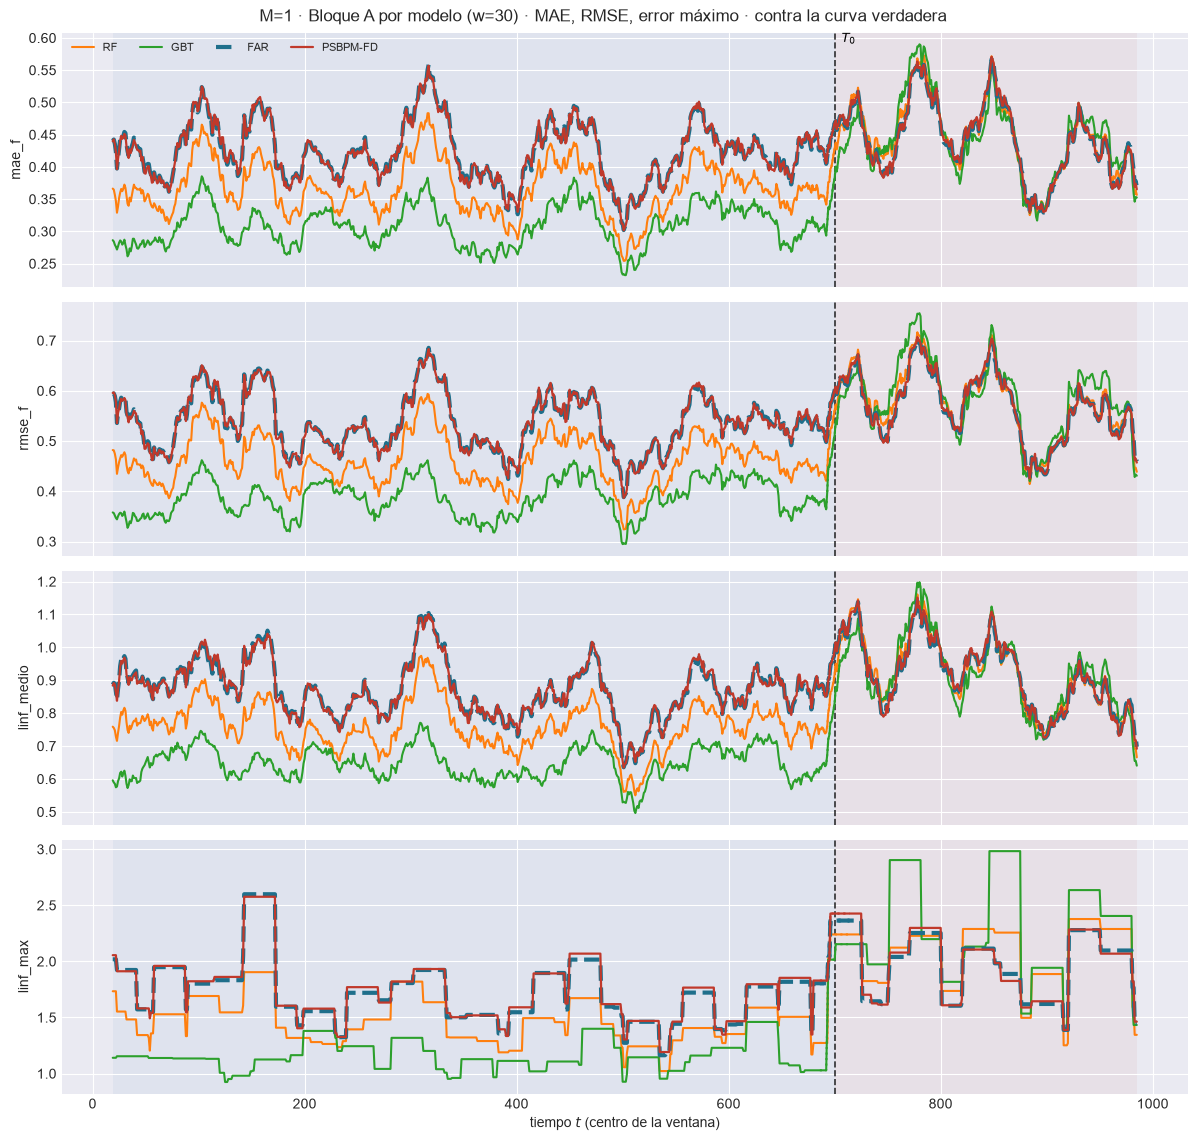

[M=1] Bloque A dibujado para ['FAR', 'GBT', 'PSBPM-FD', 'RF']


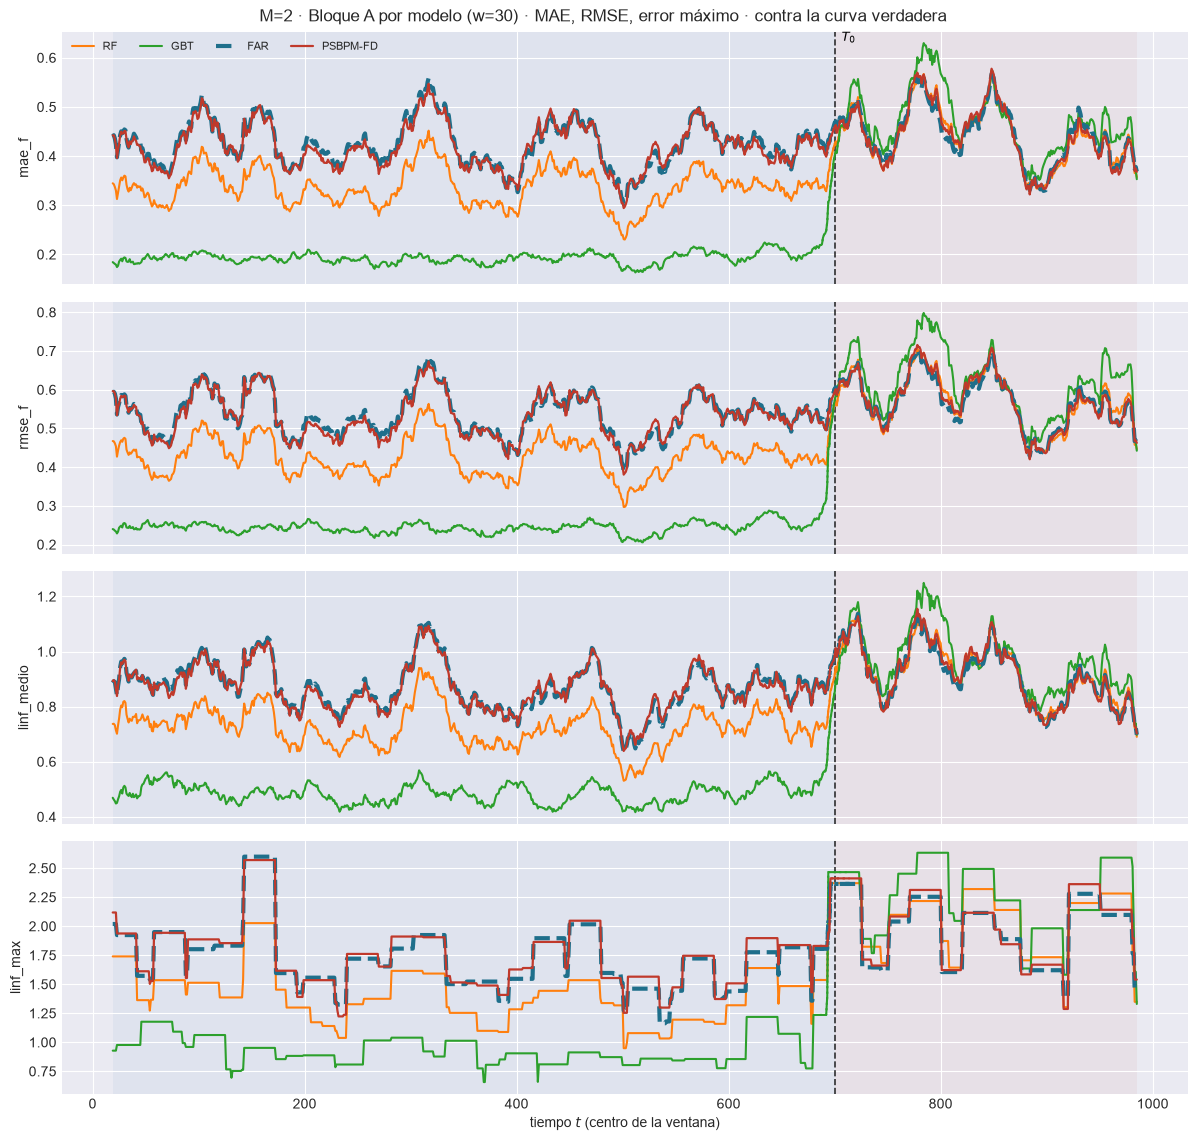

[M=2] Bloque A dibujado para ['FAR', 'GBT', 'PSBPM-FD', 'RF']


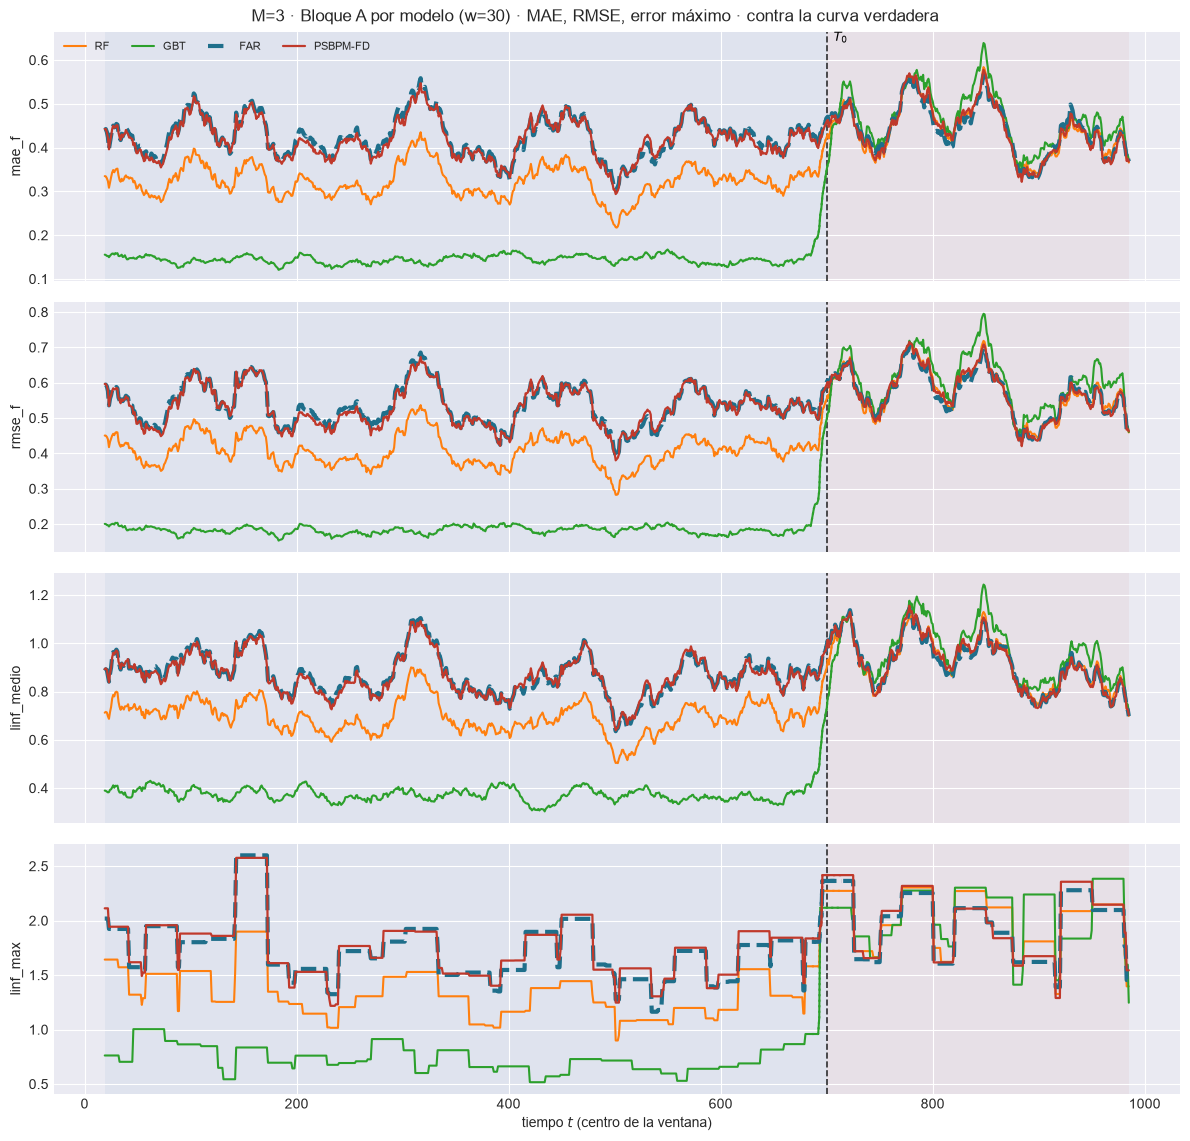

[M=3] Bloque A dibujado para ['FAR', 'GBT', 'PSBPM-FD', 'RF']


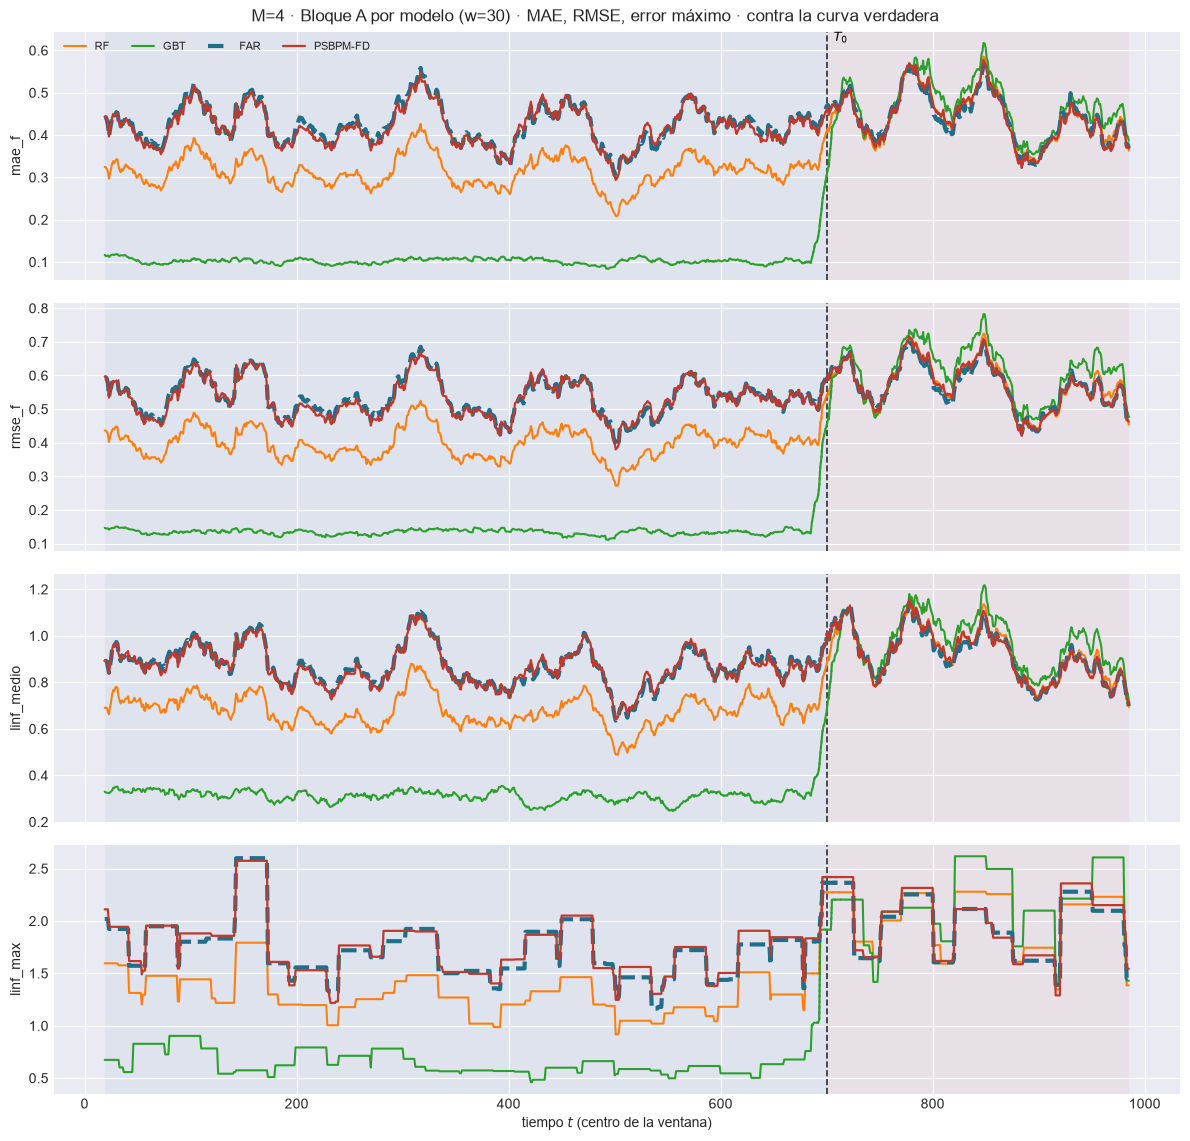

[M=4] Bloque A dibujado para ['FAR', 'GBT', 'PSBPM-FD', 'RF']


In [15]:
# Bloque A por modelo, en una sola vista. `tablas_w` ya trae las columnas
# -tabla_ventana llama a ventana_movil_funcional con bloque_A=True-.
fuera = set(EXCLUIR_DE_FIGURA)

for M in EST:
    e = EST[M]
    tw = e["tablas_w"][W_COMP]
    tf = tw[~tw["modelo"].isin(fuera)].copy()
    tf.attrs["w"] = W_COMP

    faltan = [c for c in METRICAS_A_COLS if c not in tf.columns]
    assert not faltan, f"[M={M}] faltan columnas del Bloque A: {faltan}"

    plot_ventana_movil(
        tf, T0, METRICAS_A_COLS, columna_grupo="modelo", estilos=ESTILOS_VENTANA,
        title=f"M={M} · Bloque A por modelo (w={W_COMP}) · "
              "MAE, RMSE, error máximo · contra la curva verdadera",
        save_path=str(e["paths"]["out_report"]
                      / f"{PREFIJO + 8}_ventana_bloqueA_modelos_w{W_COMP}.png"),
        verbose=False)
    plt.show()

    sub = tf.dropna(subset=METRICAS_A_COLS)
    faltan_ag = [c for c in ("l2_medio", "razon_agregacion") if c not in sub.columns]
    assert not faltan_ag, (
        f"[M={M}] faltan {faltan_ag}: la tabla no se genero con bloque_A=True.")

    assert (sub["mae_f"] <= sub["l2_medio"] + 1e-9).all(), (
        f"[M={M}] mae_f > l2_medio en alguna ventana: se rompio la cadena por "
        f"origen y el problema esta en como se construyo esa prediccion.")
    assert (sub["l2_medio"] <= sub["linf_medio"] + 1e-9).all(), (
        f"[M={M}] l2_medio > linf_medio en alguna ventana: idem.")


    assert (sub["l2_medio"] <= sub["rmse_f"] + 1e-9).all(), (
        f"[M={M}] l2_medio > rmse_f: imposible por Jensen; revise la agregacion.")

    _jen = sub[sub["rmse_f"] > sub["linf_medio"] + 1e-9]
    if len(_jen):
        print(f"[M={M}] Jensen: {len(_jen)}/{len(sub)} ventanas con "
              f"rmse_f > linf_medio (media cuadratica vs aritmetica). "
              f"exceso relativo maximo {((_jen['rmse_f'] / _jen['linf_medio']) - 1).max():.2%}"
              f" · razon_agregacion minima {_jen['razon_agregacion'].min():.3f}"
              f" · modelos {sorted(_jen['modelo'].unique())}")
    print(f"[M={M}] Bloque A dibujado para {sorted(sub['modelo'].unique())}")


## 5. Bloque B: intervalos, sólo FAR y PSBPM-FD

Las **mismas cuatro cifras** que `106_04` —Winkler, cobertura simultánea,
cobertura puntual y MPIW— sobre la misma ventana móvil.

La diferencia con el Bloque A es a qué modelos aplica. El FAR **no** es un
algoritmo de predicción puntual: es un modelo, $X_{t+1}=\rho(X_t)+\varepsilon$,
de modo que su intervalo a un paso sale de su propia especificación y no de un
procedimiento adosado. El PSBPM-FD tiene su predictiva muestreada. RF, GBT y
las líneas base no son modelos de probabilidad: rellenarles una banda
gaussiana de residuos dentro de muestra las haría parecer artificialmente
angostas y decidiría la comparación por el supuesto, no por el método.

In [16]:
# Construcción de las bandas. Los residuos son los del bloque de
# entrenamiento contra la curva VERDADERA, que es el objetivo de evaluación.
BANDAS = {}          # {M: {nombre_fila: (li, ls)}}

for M in EST:
    e = EST[M]
    n_train = int(es_train.sum())
    corr = (np.sqrt(1.0 + e["far_kn"] / n_train)
            if IC_CORRECCION_ESTIMACION else None)

    bandas = {}

    # -- FAR: el intervalo que implica su propio modelo --------------------
    # K completo, igual que en el Bloque A: las dos filas del FAR -banda y
    # error puntual- tienen que salir de la MISMA curva predicha.
    X_far = CURVA_DIRECTA["FAR"]
    r_far = residuos_para_banda(X_obj_ev, X_far, es_train)
    bandas["FAR (IC del modelo AR)"] = (
        banda_predictiva_modelo(X_far, r_far, nivel=NIVEL_IC,
                                por_tau=IC_POR_TAU,
                                correccion_estimacion=corr),
        X_far)

    # -- PSBPM-FD: la MISMA banda, para aislar el mecanismo ----------------
    if IC_PSBP_TAMBIEN_GAUSSIANA and e["X_pred_psbp"] is not None:
        r_ps = residuos_para_banda(X_obj_ev, e["X_pred_psbp"], es_train)
        bandas["PSBPM-FD (IC gaussiano, mismo mecanismo)"] = (
            banda_predictiva_modelo(e["X_pred_psbp"], r_ps, nivel=NIVEL_IC,
                                    por_tau=IC_POR_TAU,
                                    correccion_estimacion=corr),
            e["X_pred_psbp"])

    # -- PSBPM-FD: su banda nativa, leída del artefacto del _04 ------------
    npz = e["paths"]["predict"] / "banda_funcional_psbp.npz"
    if npz.exists():
        z = np.load(npz, allow_pickle=False)
        assert z["li"].shape == X_obj_ev.shape, (
            f"[M={M}] la banda del _04 es {z['li'].shape} y aquí hay "
            f"{X_obj_ev.shape}: ¿corrieron con distinta partición?")
        assert abs(float(z["nivel"][0]) - NIVEL_IC) < 1e-9, (
            f"[M={M}] el _04 usó nivel {float(z['nivel'][0])} y aquí NIVEL_IC="
            f"{NIVEL_IC}: el Winkler de las dos filas no sería comparable.")
        bandas["PSBPM-FD (predictiva bayesiana)"] = (
            (z["li"].astype(float), z["ls"].astype(float)),
            z["X_pred"].astype(float))
    else:
        print(f"! [M={M}] falta {npz.name}: ejecuta 106_04 para persistir la "
              "banda nativa. Van solo las filas gaussianas.")

    BANDAS[M] = bandas
    sd = sigma_residual(r_far, por_tau=IC_POR_TAU)
    print(f"M={M}  kn={e['far_kn']}  corrección={corr if corr else 1.0:.4f}  "
          f"sigma_eps(tau) del FAR: min={sd.min():.4f} máx={sd.max():.4f} "
          f"(razón {sd.max()/sd.min():.2f})  ·  filas: {len(bandas)}")


M=1  kn=1  corrección=1.0007  sigma_eps(tau) del FAR: min=0.3824 máx=0.7206 (razón 1.88)  ·  filas: 3
M=2  kn=1  corrección=1.0007  sigma_eps(tau) del FAR: min=0.3824 máx=0.7206 (razón 1.88)  ·  filas: 3
M=3  kn=1  corrección=1.0007  sigma_eps(tau) del FAR: min=0.3824 máx=0.7206 (razón 1.88)  ·  filas: 3
M=4  kn=1  corrección=1.0007  sigma_eps(tau) del FAR: min=0.3824 máx=0.7206 (razón 1.88)  ·  filas: 3


In [17]:
# Las cuatro cifras del Bloque B, por fila y por bloque. El Winkler es la
# PRIMARIA; picp y mpiw son su descomposición y no ordenan nada por su cuenta.
for M in EST:
    e = EST[M]
    # Los dos objetivos de docs 03_05_00. La banda del FAR vive en los K
    # coeficientes y la del PSBPM-FD en las M autofunciones: contra un objetivo
    # unico uno de los dos paga un truncamiento que el otro no paga.
    OBJETIVOS_B = (("curva_suavizada", X_obj_ev),
                   ("representacion_fpca", e["X_proj"]))
    filas = []
    for objetivo, Y in OBJETIVOS_B:
        for nombre, ((li, ls), _Xp) in BANDAS[M].items():
            for etq, mask in (("train", es_train), ("test", ~es_train)):
                r = resumen_intervalo(Y[mask], li[mask], ls[mask],
                                      nivel=NIVEL_IC, tau=grilla)
                picp_si = float(indicador_cobertura_simultanea(
                    Y[mask], li[mask], ls[mask]).mean())
                filas.append({"objetivo": objetivo, "banda": nombre,
                              "bloque": etq,
                              **{k: r[k] for k in
                                 ("winkler", "picp", "ee_picp", "ace", "mpiw")},
                              "picp_simultaneo": picp_si})
    B_df = (pd.DataFrame(filas)
            .set_index(["bloque", "objetivo", "banda"]).sort_index())
    B_df.to_csv(e["paths"]["out_report"] / "80_bloqueB_modelos.csv")
    e["B_modelos"] = B_df

    display(B_df.loc["test"].style
            .format({"winkler": "{:.4f}", "picp": "{:.4f}", "ee_picp": "{:.4f}",
                     "ace": "{:+.4f}", "mpiw": "{:.4f}",
                     "picp_simultaneo": "{:.4f}"})
            .background_gradient(subset=["winkler"], cmap="RdYlGn_r")
            .set_caption(f"M={M} · Bloque B, bloque de PRUEBA · PRIMARIA: "
                         f"winkler · nivel nominal {NIVEL_IC:.0%}"))

    # La lectura de tres filas, que es la razón de haberlas construido, leída
    # contra cada objetivo por separado.
    g_far = "FAR (IC del modelo AR)"
    g_psg = "PSBPM-FD (IC gaussiano, mismo mecanismo)"
    g_psb = "PSBPM-FD (predictiva bayesiana)"
    for objetivo, _ in OBJETIVOS_B:
        te_ = B_df.loc[("test", objetivo)]
        if {g_far, g_psg} <= set(te_.index):
            d_modelo = te_.loc[g_psg, "winkler"] - te_.loc[g_far, "winkler"]
            print(f"[M={M}] {objetivo:<20} mismo MECANISMO, distinto MODELO: "
                  f"PSBPM-FD - FAR = {d_modelo:+.4f} de Winkler")
        if {g_psg, g_psb} <= set(te_.index):
            d_mec = te_.loc[g_psb, "winkler"] - te_.loc[g_psg, "winkler"]
            print(f"        {objetivo:<20} mismo MODELO, distinto MECANISMO: "
                  f"bayesiana - gaussiana = {d_mec:+.4f}")
        print("        Si el segundo domina al primero, lo que separa a las")
        print("        filas es la forma de la predictiva y no la calidad de la")
        print("        media condicional; si domina el primero, al revés.")


[M=1] curva_suavizada      mismo MECANISMO, distinto MODELO: PSBPM-FD - FAR = +0.0150 de Winkler
        curva_suavizada      mismo MODELO, distinto MECANISMO: bayesiana - gaussiana = +2.1001
        Si el segundo domina al primero, lo que separa a las
        filas es la forma de la predictiva y no la calidad de la
        media condicional; si domina el primero, al revés.
[M=1] representacion_fpca  mismo MECANISMO, distinto MODELO: PSBPM-FD - FAR = +0.0175 de Winkler
        representacion_fpca  mismo MODELO, distinto MECANISMO: bayesiana - gaussiana = -0.8216
        Si el segundo domina al primero, lo que separa a las
        filas es la forma de la predictiva y no la calidad de la
        media condicional; si domina el primero, al revés.


[M=2] curva_suavizada      mismo MECANISMO, distinto MODELO: PSBPM-FD - FAR = +0.0379 de Winkler
        curva_suavizada      mismo MODELO, distinto MECANISMO: bayesiana - gaussiana = -0.1768
        Si el segundo domina al primero, lo que separa a las
        filas es la forma de la predictiva y no la calidad de la
        media condicional; si domina el primero, al revés.
[M=2] representacion_fpca  mismo MECANISMO, distinto MODELO: PSBPM-FD - FAR = +0.0416 de Winkler
        representacion_fpca  mismo MODELO, distinto MECANISMO: bayesiana - gaussiana = -0.2566
        Si el segundo domina al primero, lo que separa a las
        filas es la forma de la predictiva y no la calidad de la
        media condicional; si domina el primero, al revés.


[M=3] curva_suavizada      mismo MECANISMO, distinto MODELO: PSBPM-FD - FAR = +0.0383 de Winkler
        curva_suavizada      mismo MODELO, distinto MECANISMO: bayesiana - gaussiana = -0.2322
        Si el segundo domina al primero, lo que separa a las
        filas es la forma de la predictiva y no la calidad de la
        media condicional; si domina el primero, al revés.
[M=3] representacion_fpca  mismo MECANISMO, distinto MODELO: PSBPM-FD - FAR = +0.0455 de Winkler
        representacion_fpca  mismo MODELO, distinto MECANISMO: bayesiana - gaussiana = -0.2540
        Si el segundo domina al primero, lo que separa a las
        filas es la forma de la predictiva y no la calidad de la
        media condicional; si domina el primero, al revés.


[M=4] curva_suavizada      mismo MECANISMO, distinto MODELO: PSBPM-FD - FAR = +0.0383 de Winkler
        curva_suavizada      mismo MODELO, distinto MECANISMO: bayesiana - gaussiana = -0.2632
        Si el segundo domina al primero, lo que separa a las
        filas es la forma de la predictiva y no la calidad de la
        media condicional; si domina el primero, al revés.
[M=4] representacion_fpca  mismo MECANISMO, distinto MODELO: PSBPM-FD - FAR = +0.0330 de Winkler
        representacion_fpca  mismo MODELO, distinto MECANISMO: bayesiana - gaussiana = -0.2701
        Si el segundo domina al primero, lo que separa a las
        filas es la forma de la predictiva y no la calidad de la
        media condicional; si domina el primero, al revés.


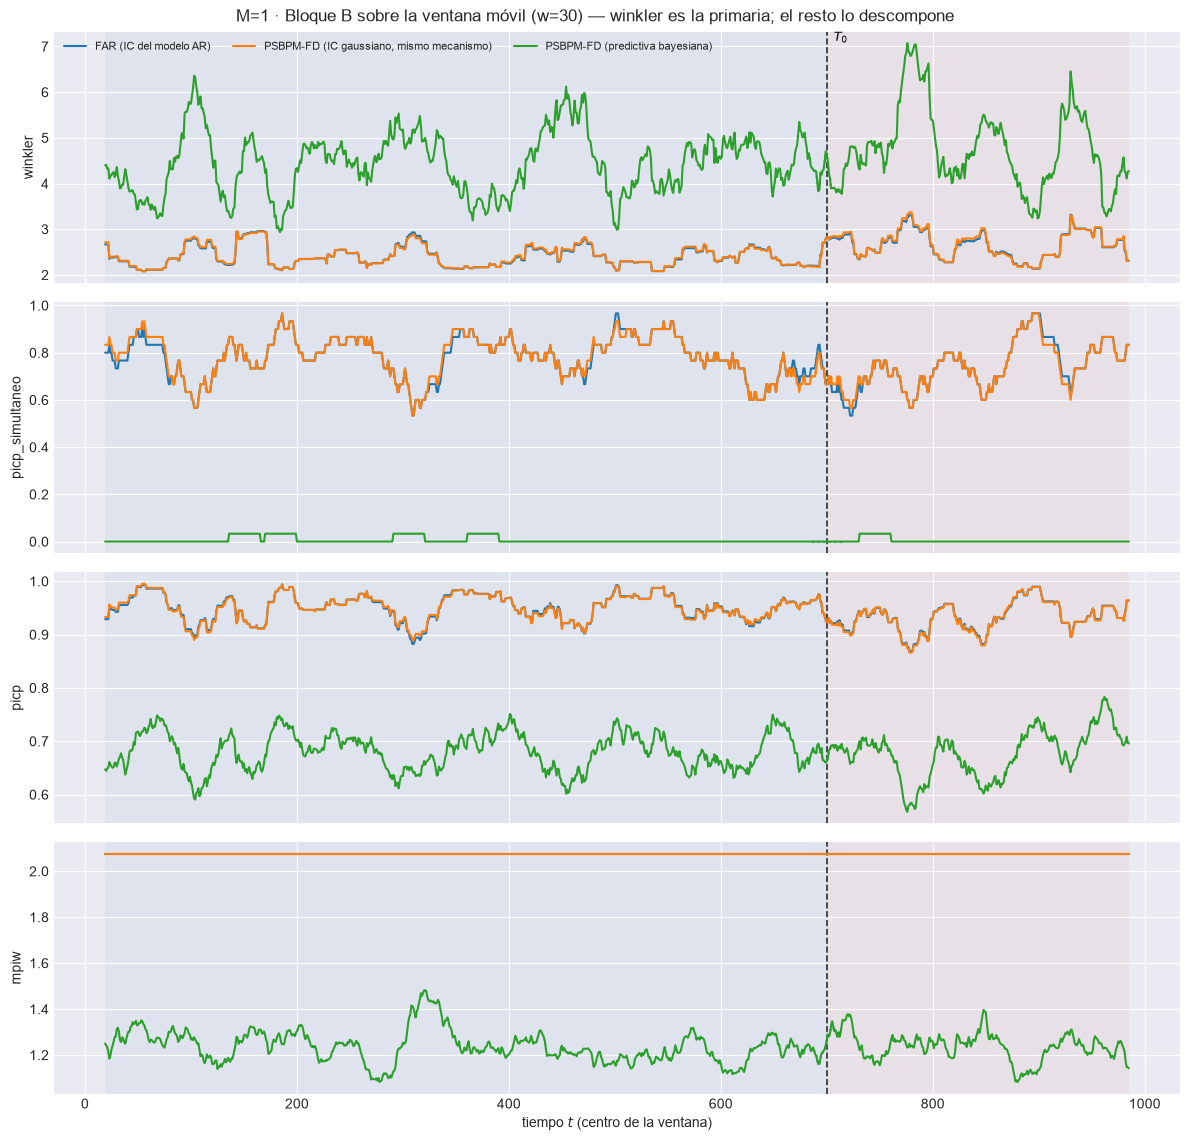

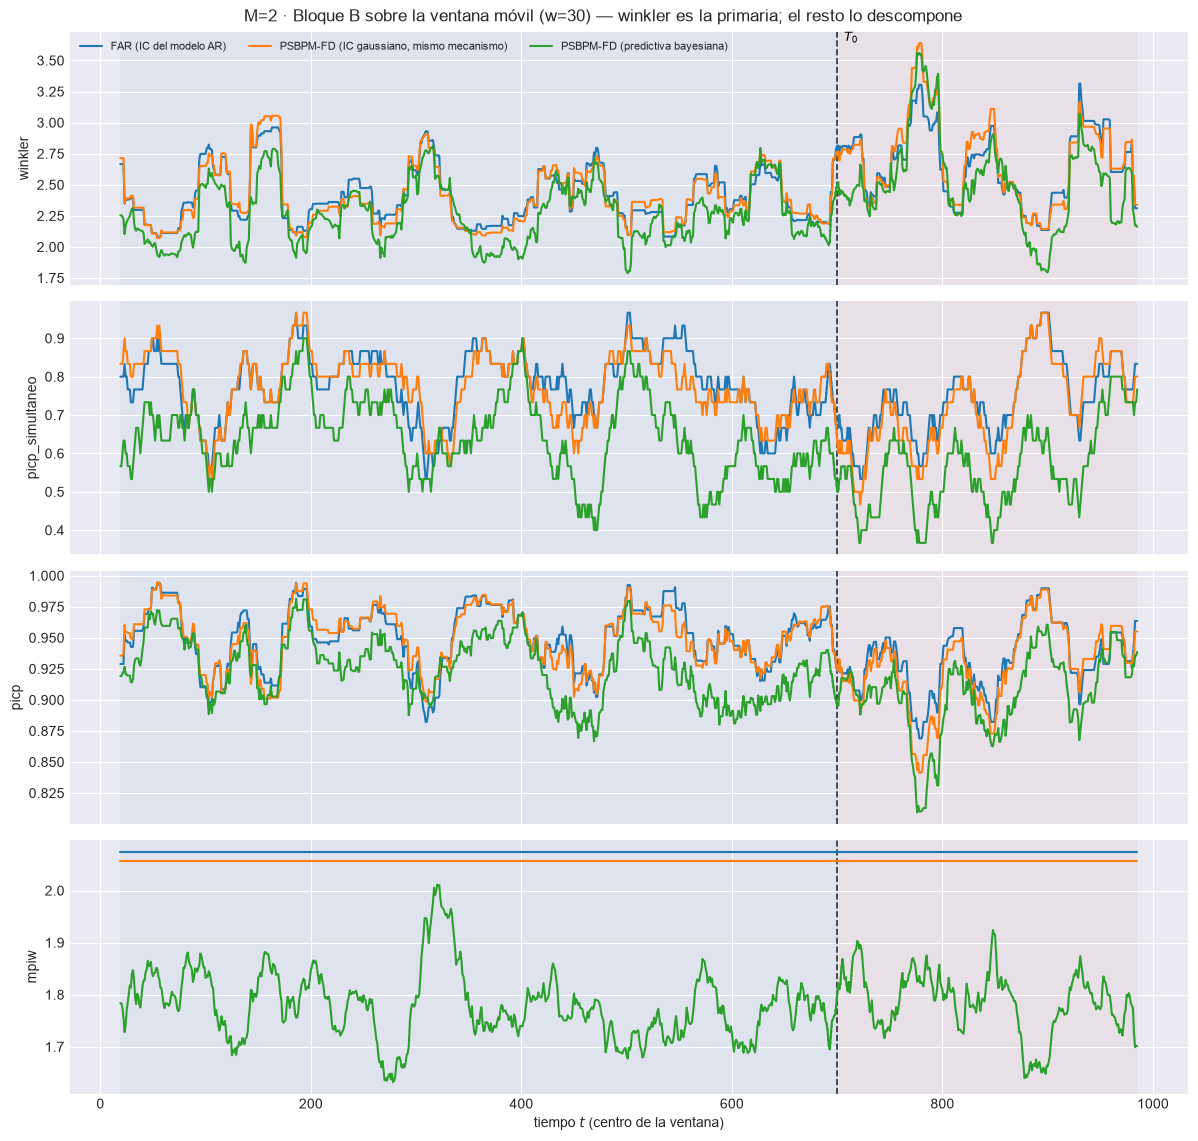

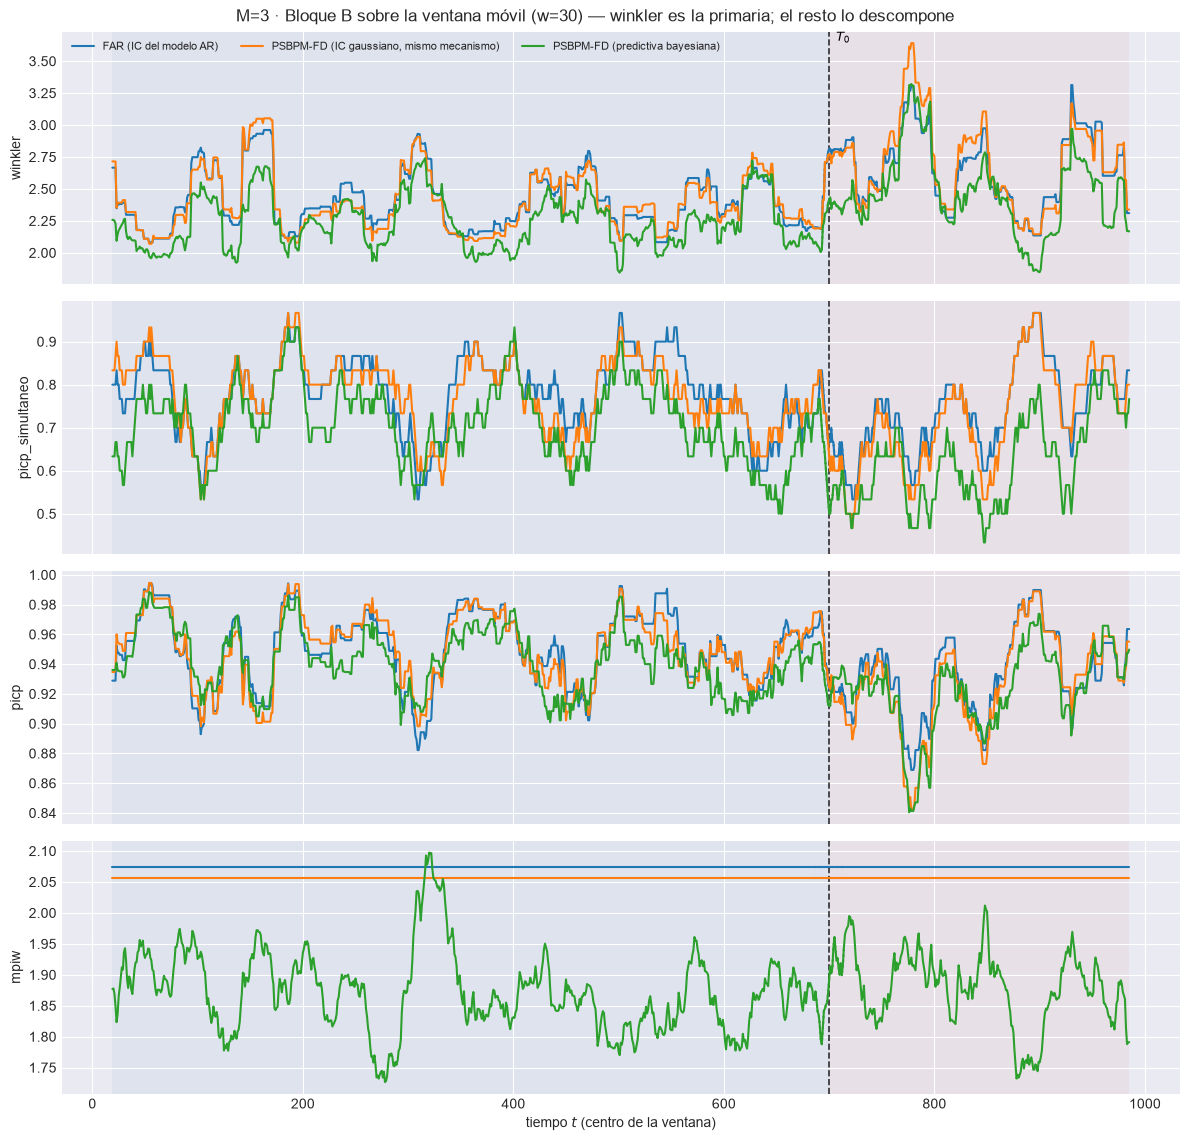

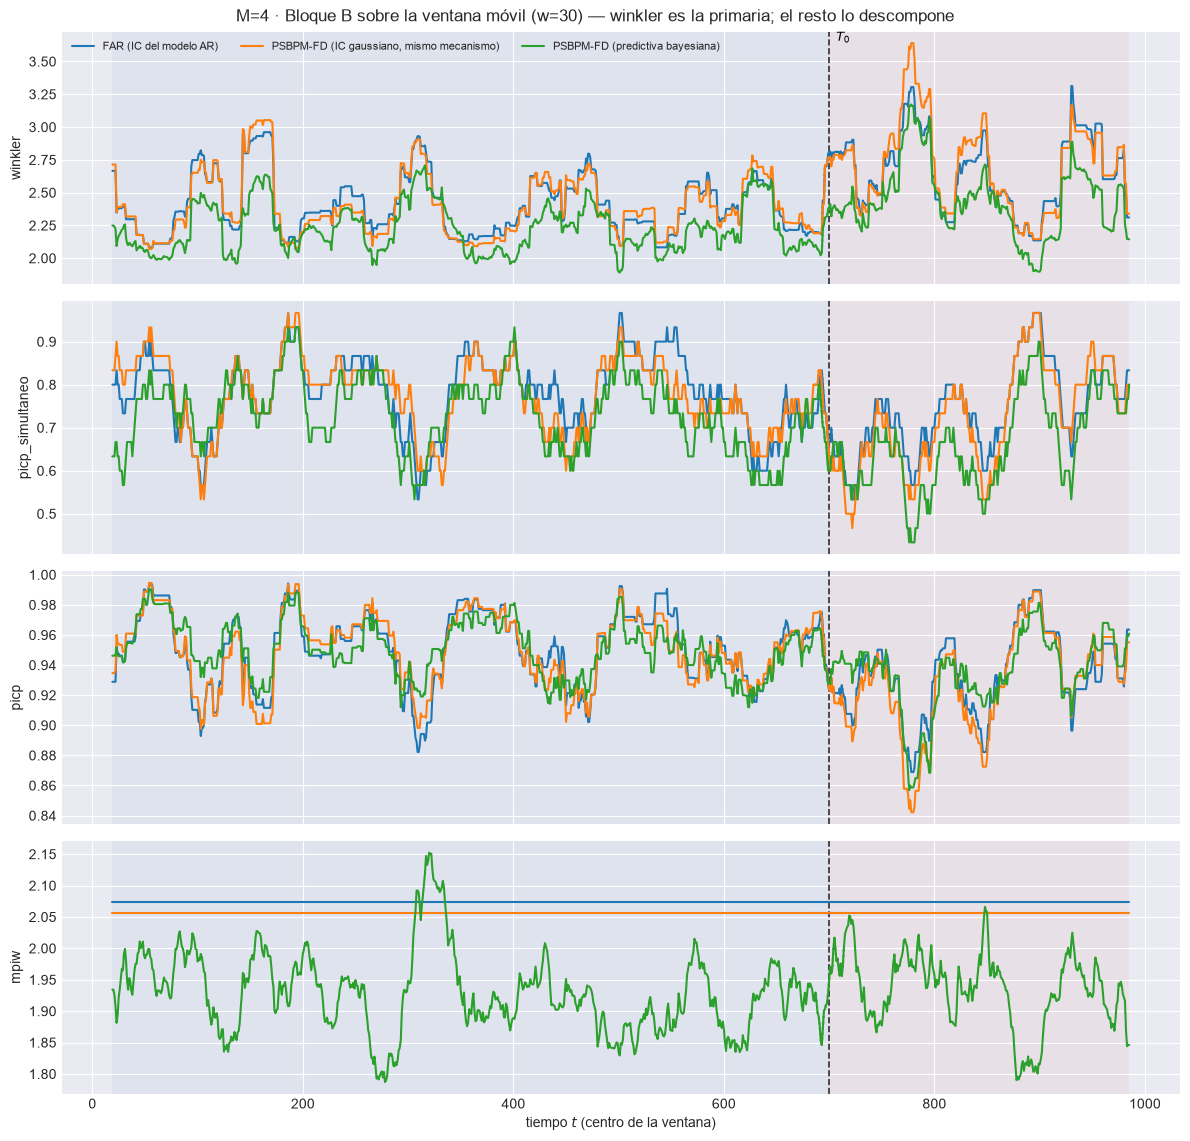

In [18]:
# Winkler sobre la ventana móvil, y su descomposición. Es la vista que dice
# CUÁNDO la banda falla, no solo cuánto: una cobertura marginal correcta puede
# esconder rachas enteras de violaciones.

for M in EST:
    e = EST[M]
    partes = []
    for nombre, ((li, ls), Xp) in BANDAS[M].items():
        t_ = ventana_movil_funcional(X_obj_ev, Xp, grilla, T0_orig, w=W_COMP,
                                     li=li, ls=ls, t_offset=N_LAGS,
                                     pesos_tau=PESOS_TAU,
                                     nivel=NIVEL_IC, bloque_A=True,
                                     verbose=False)
        t_["banda"] = nombre
        partes.append(t_)
    vb = pd.concat(partes, ignore_index=True)
    vb.attrs["w"] = W_COMP
    vb.to_csv(e["paths"]["out_report"] / f"81_ventana_bloqueB_w{W_COMP}.csv",
              index=False)
    e["ventana_B"] = vb

    plot_ventana_movil(
        vb, T0, ["winkler", "picp_simultaneo", "picp", "mpiw"], columna_grupo="banda",
        title=f"M={M} · Bloque B sobre la ventana móvil (w={W_COMP}) — "
              "winkler es la primaria; el resto lo descompone",
        save_path=str(e["paths"]["out_report"]
                      / f"81_ventana_bloqueB_w{W_COMP}.png"),
        verbose=False)
    plt.show()

    # El indicador I_t por origen, puntual y simultaneo, del que picp y
    # picp_simultaneo son el promedio respectivo. Se persiste por banda para
    # poder ver DONDE falla, no solo cuanto en promedio.
    for nombre, ((li, ls), _Xp) in BANDAS[M].items():
        I_t_pt = indicador_cobertura(X_obj_ev, li, ls).mean(axis=1)
        I_t_si = indicador_cobertura_simultanea(X_obj_ev, li, ls)
        ind = pd.DataFrame({"t": np.arange(len(I_t_pt)) + N_LAGS + 1,
                            "bloque": np.where(es_train, "train", "test"),
                            "banda": nombre, "I_t_puntual": I_t_pt,
                            "I_t_simultaneo": I_t_si.astype(float)})
        ind.to_csv(e["paths"]["out_report"]
                  / f"81b_indicador_cobertura_{nombre.split(' ')[0]}.csv",
                  index=False)


## 6. Bloque A: quién gana cada ventana, y por cuánto

Dos lecturas distintas y complementarias sobre la misma tabla de ventana:

1. **% de ventanas ganadas** — para cada ventana se marca el modelo con el
   valor más bajo de la métrica. Es una lectura más dura que el promedio: un
   modelo puede tener mejor promedio y ganar pocas ventanas si pierde por poco
   muchas veces y gana por mucho unas pocas.
2. **Cuánto mejor** — la razón de cada modelo contra el mejor de la ventana y
   contra el FAR, la referencia lineal (mal especificada: el generador es una
   mezcla de mecanismos, no un único operador).

Ambas se calculan sobre las ventanas que **no cruzan $T_0$**.

In [19]:
# (1) % de ventanas ganadas por modelo, y (2) cuanto mejor/peor es cada uno.
gana_A, rel_A = [], []
for M in EST:
    e = EST[M]
    tw = e["tablas_w"][W_COMP]
    limpio = tw[~tw["cruza_T0"]]
    modelos = [m for m in limpio["modelo"].unique() if m not in fuera]

    for etiqueta, col in METRICAS_A:
        piv = limpio.pivot_table(index=["t_centro", "bloque"], columns="modelo",
                                 values=col)[modelos]
        ganador = piv.idxmin(axis=1)
        for bloque in ("train", "test"):
            sel = ganador.index.get_level_values("bloque") == bloque
            sub = ganador[sel]
            n_tot = len(sub)
            for m in modelos:
                gana_A.append({
                    "M": M, "metrica": etiqueta, "columna": col,
                    "bloque": bloque, "modelo": m,
                    "pct_ventanas_ganadas": float((sub == m).mean()) if n_tot else np.nan,
                    "n_ventanas": n_tot})

            # (2) cuanto mejor: razon contra el mejor de cada ventana y contra
            # el FAR. Se promedia la RAZON por ventana, no se divide el
            # promedio: asi cada ventana pesa igual y no la dominan las de
            # error grande.
            p = piv[sel]
            mejor = p.min(axis=1)
            for m in modelos:
                fila = {"M": M, "metrica": etiqueta, "bloque": bloque, "modelo": m,
                        "razon_vs_mejor": float((p[m] / mejor).mean())}
                if "FAR" in p.columns:
                    fila["razon_vs_FAR"] = float((p[m] / p["FAR"]).mean())
                rel_A.append(fila)

gana_A_df = pd.DataFrame(gana_A)
rel_A_df  = pd.DataFrame(rel_A)
gana_A_df.to_csv(PATH_BARRIDO / "96_ganador_ventana_bloqueA.csv", index=False)
rel_A_df.to_csv(PATH_BARRIDO / "96_razones_bloqueA.csv", index=False)

for etiqueta, _col in METRICAS_A:
    piv_g = (gana_A_df[(gana_A_df.metrica == etiqueta) & (gana_A_df.bloque == "test")]
             .pivot(index="modelo", columns="M", values="pct_ventanas_ganadas"))
    display(piv_g.style.format("{:.1%}", na_rep="-")
            .background_gradient(cmap="RdYlGn", axis=None)
            .set_caption(f"{etiqueta} · % de ventanas de PRUEBA ganadas "
                         f"(w={W_COMP}, sin cruzar T0)"))

for etiqueta, _col in METRICAS_A:
    piv_r = (rel_A_df[(rel_A_df.metrica == etiqueta) & (rel_A_df.bloque == "test")]
             .pivot(index="modelo", columns="M", values="razon_vs_mejor"))
    display(piv_r.style.format("{:.3f}", na_rep="-")
            .background_gradient(cmap="RdYlGn_r", axis=None)
            .set_caption(f"{etiqueta} · razón contra el MEJOR de cada ventana "
                         "(test) · 1.000 = gana siempre"))


M,1,2,3,4
modelo,,,,
FAR,31.0%,26.9%,34.3%,36.2%
GBT,35.8%,7.7%,3.0%,0.7%
PSBPM-FD,21.0%,32.8%,33.9%,37.3%
RF,12.2%,32.5%,28.8%,25.8%


M,1,2,3,4
modelo,,,,
FAR,37.6%,37.6%,45.8%,48.0%
GBT,25.1%,3.0%,1.1%,4.8%
PSBPM-FD,22.5%,24.7%,24.7%,31.0%
RF,14.8%,34.7%,28.4%,16.2%


M,1,2,3,4
modelo,,,,
FAR,29.9%,29.9%,40.2%,43.9%
GBT,38.4%,7.0%,4.4%,2.6%
PSBPM-FD,15.1%,42.1%,40.2%,44.3%
RF,16.6%,21.0%,15.1%,9.2%


M,1,2,3,4
modelo,,,,
FAR,42.1%,60.5%,49.8%,32.8%
GBT,12.2%,12.2%,23.6%,17.0%
PSBPM-FD,34.3%,14.8%,22.1%,25.8%
RF,11.4%,12.5%,4.4%,24.4%


M,1,2,3,4
modelo,,,,
FAR,1.020,1.017,1.016,1.014
GBT,1.030,1.086,1.074,1.076
PSBPM-FD,1.021,1.014,1.014,1.012
RF,1.028,1.015,1.015,1.018


M,1,2,3,4
modelo,,,,
FAR,1.012,1.010,1.009,1.008
GBT,1.047,1.104,1.079,1.088
PSBPM-FD,1.014,1.013,1.013,1.011
RF,1.024,1.015,1.013,1.019


M,1,2,3,4
modelo,,,,
FAR,1.021,1.007,1.006,1.005
GBT,1.028,1.073,1.068,1.079
PSBPM-FD,1.023,1.009,1.009,1.008
RF,1.026,1.015,1.013,1.018


M,1,2,3,4
modelo,,,,
FAR,1.018,1.014,1.047,1.025
GBT,1.200,1.174,1.109,1.155
PSBPM-FD,1.021,1.030,1.064,1.042
RF,1.087,1.064,1.071,1.066


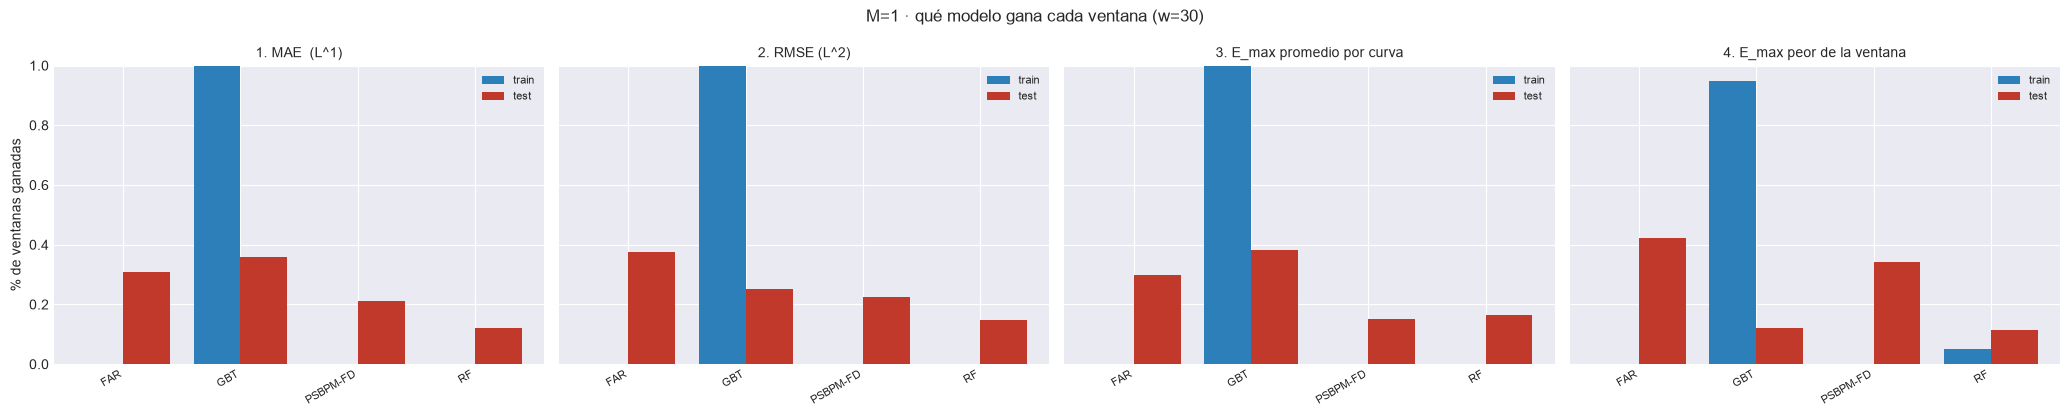

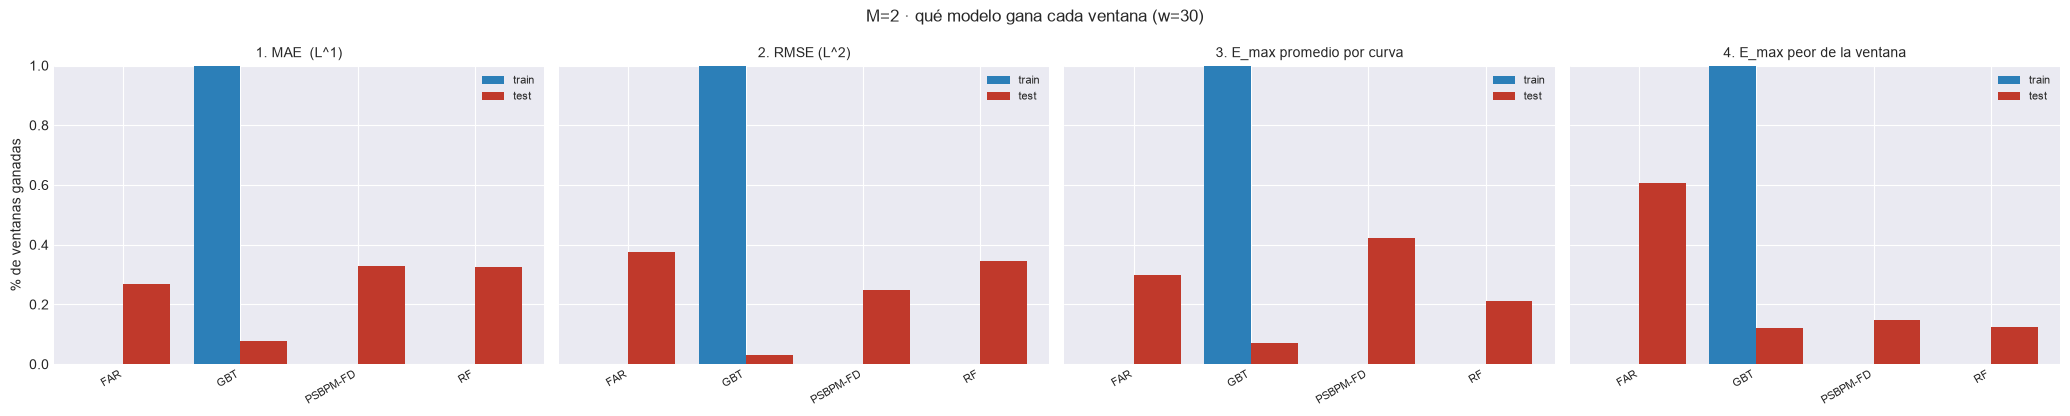

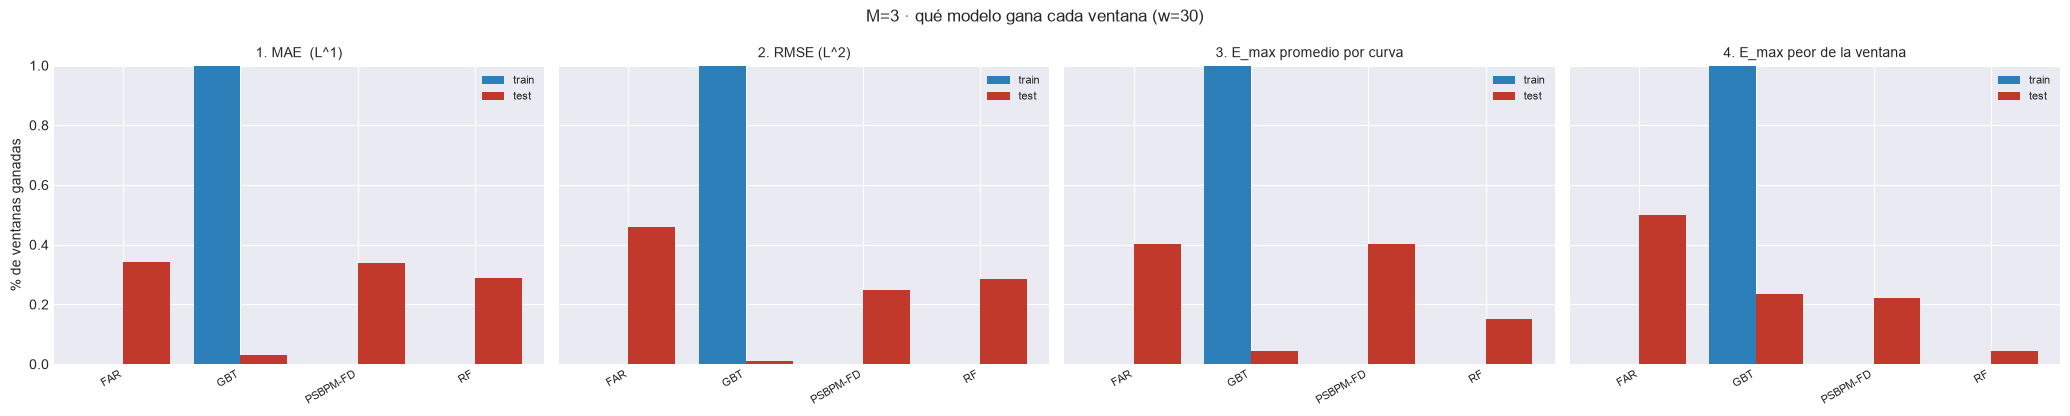

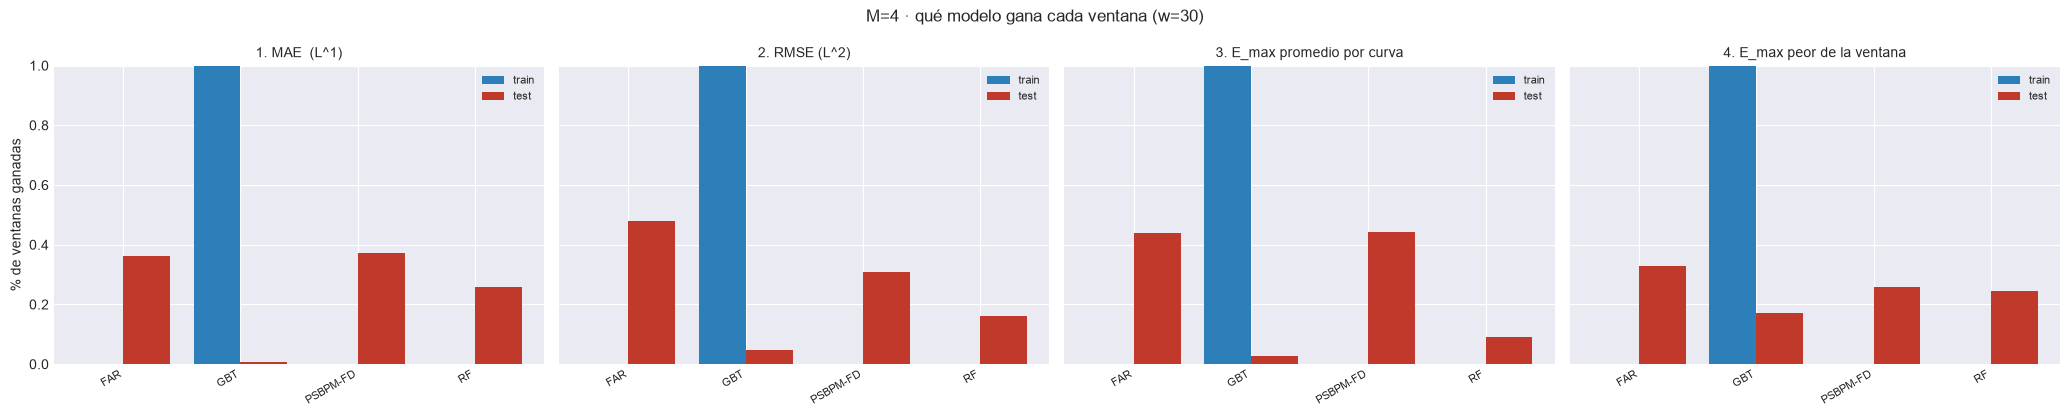

In [20]:
# Figura: % de ventanas ganadas, por modelo y metrica, train contra test.
_Ms = sorted(EST)
for M in _Ms:
    sub_M = gana_A_df[gana_A_df.M == M]
    modelos = sorted(sub_M["modelo"].unique())
    fig, axes = plt.subplots(1, len(METRICAS_A),
                             figsize=(5.2 * len(METRICAS_A), 4.2), sharey=True)
    if len(METRICAS_A) == 1:
        axes = [axes]
    ancho = 0.8 / 2
    xs = np.arange(len(modelos))
    for ax, (etiqueta, _c) in zip(axes, METRICAS_A):
        for i_b, bloque in enumerate(("train", "test")):
            vals = [float(sub_M[(sub_M.modelo == m) & (sub_M.bloque == bloque)
                                & (sub_M.metrica == etiqueta)]
                          ["pct_ventanas_ganadas"].iloc[0]) for m in modelos]
            ax.bar(xs + (i_b - 0.5) * ancho, vals, width=ancho, label=bloque,
                   color=("#2c7fb8" if bloque == "train" else "#c0392b"))
        ax.set_xticks(xs); ax.set_xticklabels(modelos, rotation=30, ha="right",
                                              fontsize=8)
        ax.set_title(etiqueta, fontsize=10); ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("% de ventanas ganadas")
    fig.suptitle(f"M={M} · qué modelo gana cada ventana (w={W_COMP})", fontsize=12)
    fig.tight_layout()
    fig.savefig(EST[M]["paths"]["out_report"]
                / f"{PREFIJO + 8}_ganador_ventana_bloqueA.png",
                dpi=150, bbox_inches="tight")
    plt.show()


## 7. Bloque B: quién gana cada ventana, y por cuánto

La misma lectura de §6, restringida a las series que **tienen un mecanismo de
intervalo propio**: el FAR —cuyo IC a un paso sale de su propia especificación
$X_{t+1}=\rho(X_t)+\varepsilon$— y el PSBPM-FD —cuya predictiva se muestrea y
cuyos cuantiles empíricos dan la banda—.

El Winkler es la única regla de puntuación propia del bloque, así que es la
que decide quién gana; PICP y MPIW lo descomponen en cobertura y ancho.

In [21]:
# % de ventanas ganadas y razones, sobre las bandas (FAR y PSBPM-FD).
# En picp / picp_simultaneo "ganar" NO es tener el valor mas bajo sino estar
# mas cerca del nominal: se compara |picp - NIVEL_IC|.
gana_B, rel_B = [], []
for M in EST:
    e = EST[M]
    vb = e["ventana_B"]
    limpio = vb[~vb["cruza_T0"]]
    bandas = list(limpio["banda"].unique())

    for etiqueta, col in METRICAS_B:
        piv = limpio.pivot_table(index=["t_centro", "bloque"], columns="banda",
                                 values=col)[bandas]
        # Criterio de "mejor" por metrica.
        objetivo = (piv - NIVEL_IC).abs() if col.startswith("picp") else piv
        ganador = objetivo.idxmin(axis=1)
        for bloque in ("train", "test"):
            sel = ganador.index.get_level_values("bloque") == bloque
            sub = ganador[sel]
            n_tot = len(sub)
            for b in bandas:
                gana_B.append({
                    "M": M, "metrica": etiqueta, "columna": col,
                    "bloque": bloque, "banda": b,
                    "pct_ventanas_ganadas": float((sub == b).mean()) if n_tot else np.nan,
                    "n_ventanas": n_tot,
                    "criterio": "|valor - nominal|" if col.startswith("picp")
                                else "menor es mejor"})
            o = objetivo[sel]
            mejor = o.min(axis=1)
            for b in bandas:
                rel_B.append({"M": M, "metrica": etiqueta, "bloque": bloque,
                              "banda": b,
                              "razon_vs_mejor": float(
                                  (o[b] / mejor.replace(0, np.nan)).mean())})

gana_B_df = pd.DataFrame(gana_B)
rel_B_df  = pd.DataFrame(rel_B)
gana_B_df.to_csv(PATH_BARRIDO / "97_ganador_ventana_bloqueB.csv", index=False)
rel_B_df.to_csv(PATH_BARRIDO / "97_razones_bloqueB.csv", index=False)

for etiqueta, col in METRICAS_B:
    piv_g = (gana_B_df[(gana_B_df.metrica == etiqueta) & (gana_B_df.bloque == "test")]
             .pivot(index="banda", columns="M", values="pct_ventanas_ganadas"))
    crit = ("más cerca del nominal" if col.startswith("picp") else "menor es mejor")
    display(piv_g.style.format("{:.1%}", na_rep="-")
            .background_gradient(cmap="RdYlGn", axis=None)
            .set_caption(f"{etiqueta} · % de ventanas de PRUEBA ganadas "
                         f"(criterio: {crit})"))


M,1,2,3,4
banda,,,,
FAR (IC del modelo AR),0.0%,0.0%,0.0%,0.0%
"PSBPM-FD (IC gaussiano, mismo mecanismo)",0.0%,0.0%,0.0%,1.1%
PSBPM-FD (predictiva bayesiana),100.0%,100.0%,100.0%,98.9%


M,1,2,3,4
banda,,,,
FAR (IC del modelo AR),72.7%,64.6%,53.1%,32.5%
"PSBPM-FD (IC gaussiano, mismo mecanismo)",27.3%,24.0%,17.7%,11.8%
PSBPM-FD (predictiva bayesiana),0.0%,11.4%,29.2%,55.7%


M,1,2,3,4
banda,,,,
FAR (IC del modelo AR),92.6%,88.6%,88.6%,87.8%
"PSBPM-FD (IC gaussiano, mismo mecanismo)",7.4%,11.4%,11.4%,11.4%
PSBPM-FD (predictiva bayesiana),0.0%,0.0%,0.0%,0.7%


M,1,2,3,4
banda,,,,
FAR (IC del modelo AR),66.8%,21.0%,14.8%,4.1%
"PSBPM-FD (IC gaussiano, mismo mecanismo)",33.2%,0.4%,0.0%,0.0%
PSBPM-FD (predictiva bayesiana),0.0%,78.6%,85.2%,95.9%


M,1,2,3,4
banda,,,,
FAR (IC del modelo AR),65.7%,62.4%,44.3%,35.4%
"PSBPM-FD (IC gaussiano, mismo mecanismo)",34.3%,25.1%,11.1%,0.7%
PSBPM-FD (predictiva bayesiana),0.0%,12.5%,44.6%,63.8%


M,1,2,3,4
banda,,,,
FAR (IC del modelo AR),49.1%,44.3%,18.5%,18.5%
"PSBPM-FD (IC gaussiano, mismo mecanismo)",50.2%,15.5%,5.9%,1.8%
PSBPM-FD (predictiva bayesiana),0.7%,40.2%,75.6%,79.7%


## 8. Cuadro resumen: mínimo, máximo y promedio

Igual que en `106_04`: la ventana móvil genera una **serie** por métrica y por
modelo, no una cifra. El resumen muestra los tres números que describen esa
serie —mínimo, máximo y promedio— por bloque train/test, excluyendo las
ventanas que cruzan $T_0$.

El **máximo** es el que no aparece en ninguna tabla de promedios y suele ser el
que decide: un modelo con buen promedio y un máximo muy alto falla feo en
algún tramo, y eso es información distinta de su error típico.

In [22]:
# Bloque A: min / max / promedio por modelo y metrica.
resA = []
for M in EST:
    e = EST[M]
    tw = e["tablas_w"][W_COMP]
    limpio = tw[~tw["cruza_T0"]]
    for etiqueta, col in METRICAS_A:
        g = limpio.groupby(["modelo", "bloque"])[col].agg(["min", "max", "mean"])
        for (modelo, bloque), r in g.iterrows():
            resA.append({"M": M, "metrica": etiqueta, "columna": col,
                         "modelo": modelo, "bloque": bloque,
                         "minimo": float(r["min"]), "maximo": float(r["max"]),
                         "promedio": float(r["mean"])})
resumen_A = pd.DataFrame(resA)
resumen_A.to_csv(PATH_BARRIDO / "98_resumen_bloqueA_min_max_prom.csv", index=False)

for M in EST:
    sub = (resumen_A[(resumen_A.M == M) & (resumen_A.bloque == "test")]
           .set_index(["metrica", "modelo"])[["minimo", "maximo", "promedio"]])
    display(sub.style.format("{:.6f}")
            .background_gradient(subset=["maximo"], cmap="RdYlGn_r")
            .set_caption(f"M={M} · Bloque A en el TEST · mínimo / máximo / "
                         f"promedio sobre las ventanas (w={W_COMP})"))


In [23]:
# Bloque B: min / max / promedio por banda y metrica.
resB = []
for M in EST:
    e = EST[M]
    vb = e["ventana_B"]
    limpio = vb[~vb["cruza_T0"]]
    for etiqueta, col in METRICAS_B:
        g = limpio.groupby(["banda", "bloque"])[col].agg(["min", "max", "mean"])
        for (banda, bloque), r in g.iterrows():
            resB.append({"M": M, "metrica": etiqueta, "columna": col,
                         "banda": banda, "bloque": bloque,
                         "minimo": float(r["min"]), "maximo": float(r["max"]),
                         "promedio": float(r["mean"])})
resumen_B = pd.DataFrame(resB)
resumen_B.to_csv(PATH_BARRIDO / "99_resumen_bloqueB_min_max_prom.csv", index=False)

for M in EST:
    sub = (resumen_B[(resumen_B.M == M) & (resumen_B.bloque == "test")]
           .set_index(["metrica", "banda"])[["minimo", "maximo", "promedio"]])
    display(sub.style.format("{:.4f}")
            .set_caption(f"M={M} · Bloque B en el TEST · mínimo / máximo / "
                         f"promedio sobre las ventanas (w={W_COMP}) · "
                         f"nivel nominal {NIVEL_IC:.0%}"))


## 9. Intervalos de credibilidad: FAR contra PSBPM-FD, curva a curva

Los promedios de §7 y §8 dicen *cuánto*, no *dónde*. Aquí se eligen los
$N$ orígenes de prueba **mejor** y **peor** predichos según
`METRICA_SEL_IC` ([CONFIG]) y se dibujan las dos bandas superpuestas sobre la
misma curva verdadera.

Es donde se ve la diferencia cualitativa que las cifras agregadas promedian: el
IC del FAR tiene **ancho que no depende del origen** —su $\Sigma_\varepsilon$
es la misma para todo $t$, de modo que sólo hereda la forma de $\tau$— mientras
que la banda del PSBPM-FD sale de los cuantiles de una predictiva que sí cambia
con el estado rezagado. En un escenario homogéneo como éste esa flexibilidad no
tiene nada que explotar y el contraste debería ser pequeño; en los escenarios
2–4 es donde tendría que verse.

In [24]:
# Seleccion de los origenes extremos por METRICA_SEL_IC, sobre el TEST.
from model_psbp_fd.fit import normas_error_por_origen

_CLAVE_NORMA = {"mae_f": "l1", "rmse_f": "l2", "linf_medio": "linf"}
assert METRICA_SEL_IC in _CLAVE_NORMA, (
    f"METRICA_SEL_IC={METRICA_SEL_IC!r} no es una del Bloque A: "
    f"{list(_CLAVE_NORMA)}")

EXTREMOS = {}
for M in EST:
    e = EST[M]
    if e["X_pred_psbp"] is None:
        print(f"[M={M}] sin PSBPM-FD: se omite §9.")
        continue
    nm = normas_error_por_origen(X_obj_ev, e["X_pred_psbp"], grilla,
                                 pesos_tau=PESOS_TAU, verificar=False)
    serie = nm[_CLAVE_NORMA[METRICA_SEL_IC]]          # (n_orig,)
    idx_test = np.where(~es_train)[0]
    orden = idx_test[np.argsort(serie[idx_test])]
    EXTREMOS[M] = {"mejores": orden[:N_EXTREMOS],
                   "peores":  orden[-N_EXTREMOS:][::-1],
                   "serie":   serie}
    print(f"[M={M}] por {METRICA_SEL_IC} (PSBPM-FD, test):")
    print(f"    mejores t = {[int(t_orig[i]) for i in orden[:N_EXTREMOS]]}")
    print(f"    peores  t = {[int(t_orig[i]) for i in orden[-N_EXTREMOS:][::-1]]}")


[M=1] por rmse_f (PSBPM-FD, test):
    mejores t = [911, 893, 832, 905, 912]
    peores  t = [711, 936, 945, 966, 968]
[M=2] por rmse_f (PSBPM-FD, test):
    mejores t = [893, 832, 769, 911, 754]
    peores  t = [936, 711, 966, 968, 838]
[M=3] por rmse_f (PSBPM-FD, test):
    mejores t = [893, 832, 769, 754, 911]
    peores  t = [936, 711, 966, 968, 838]
[M=4] por rmse_f (PSBPM-FD, test):
    mejores t = [893, 832, 769, 911, 754]
    peores  t = [936, 711, 966, 968, 838]


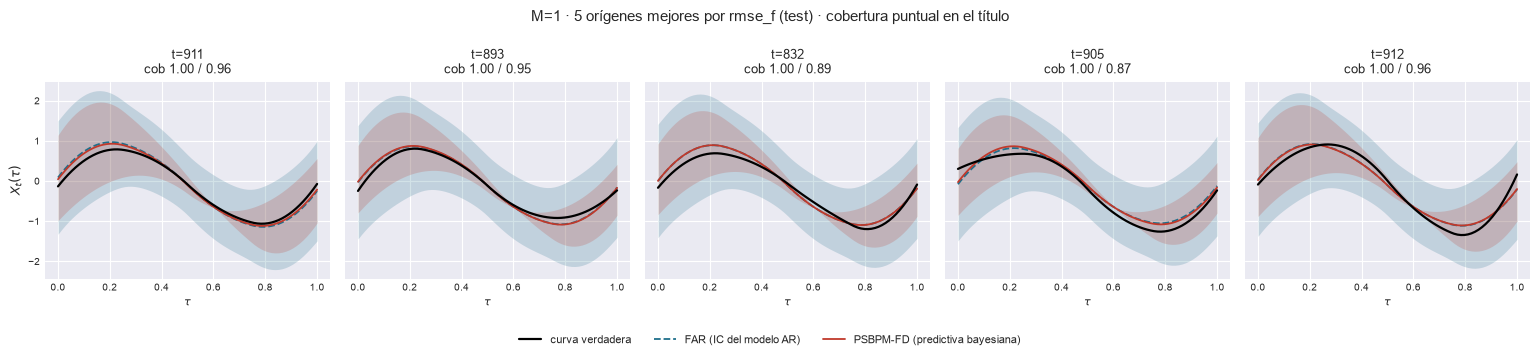

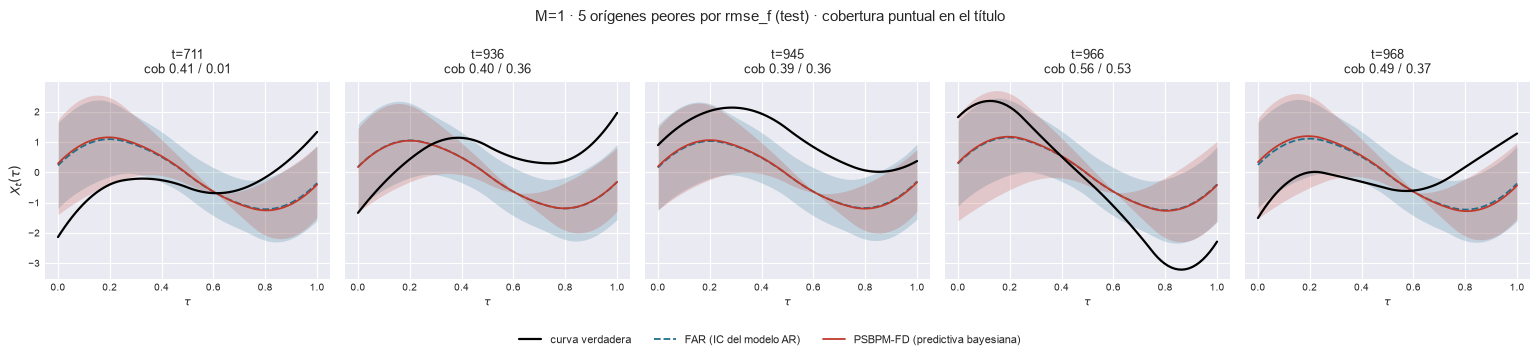

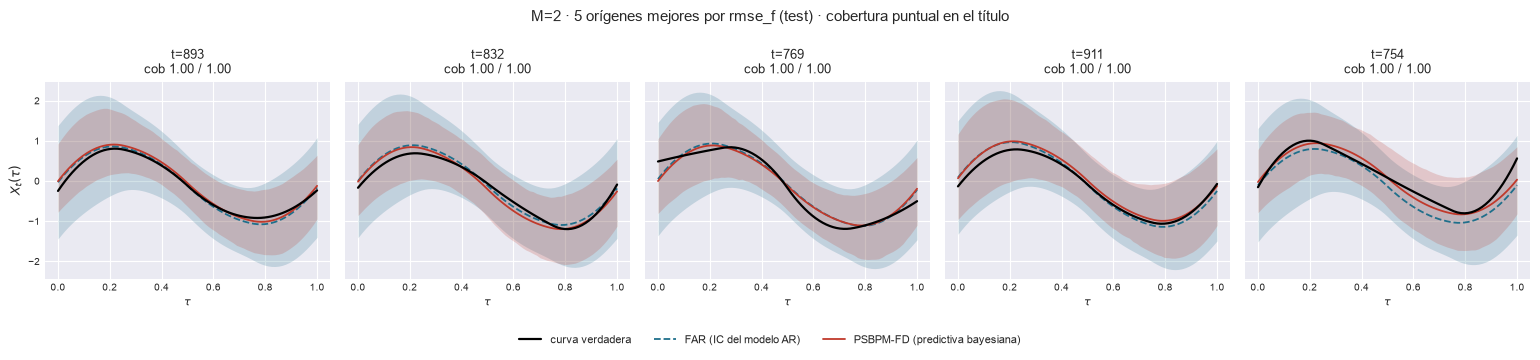

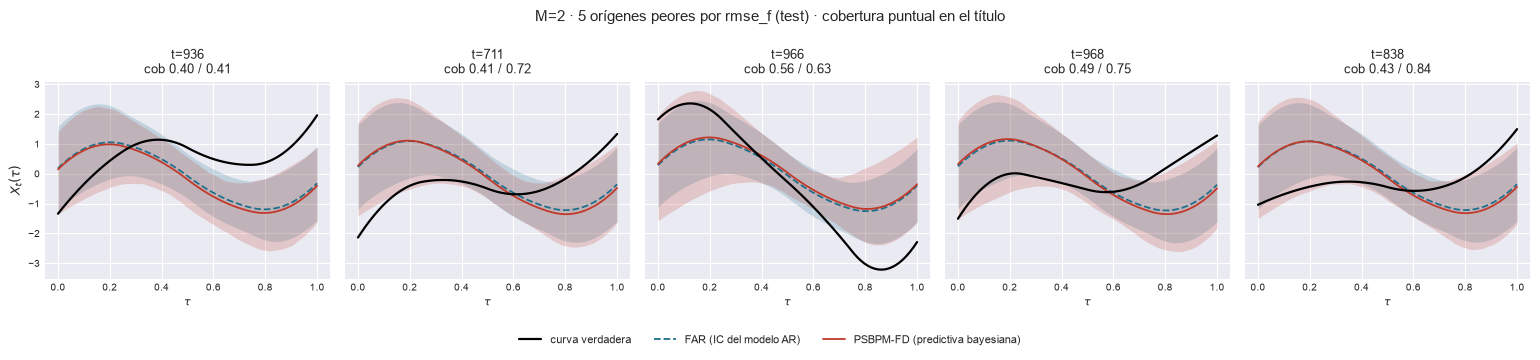

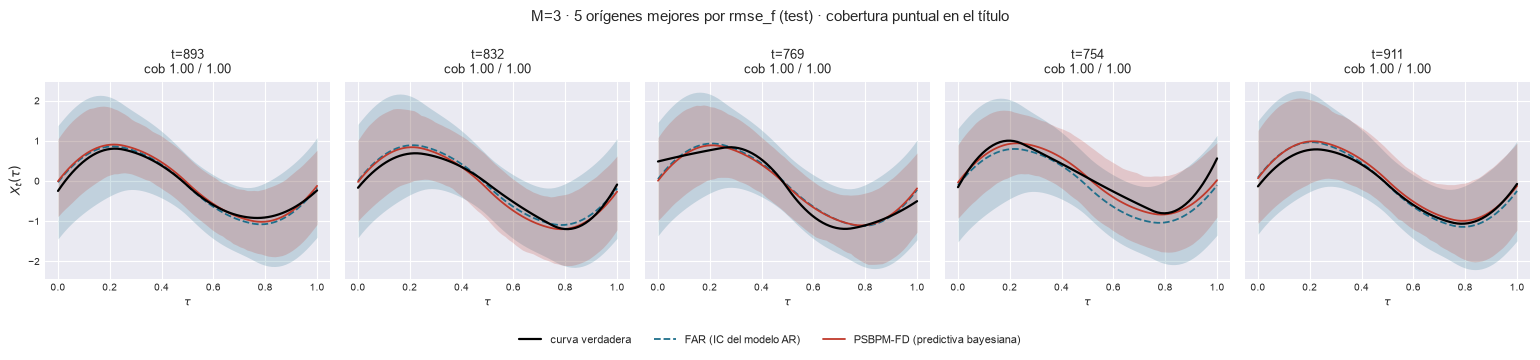

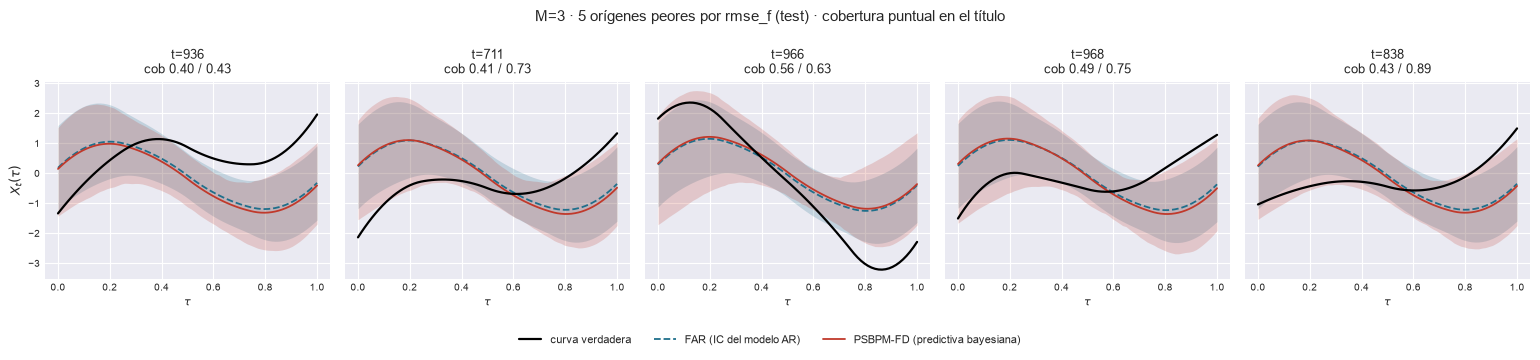

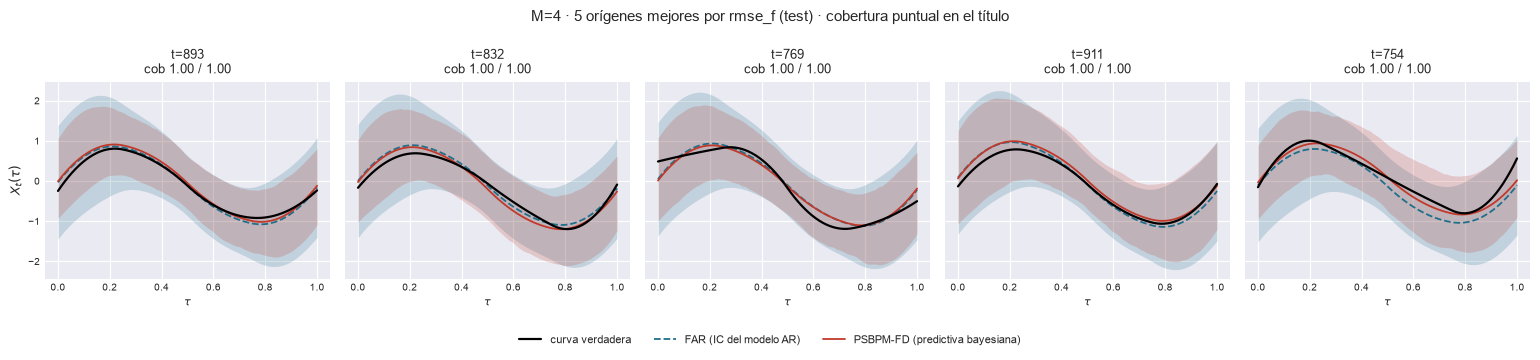

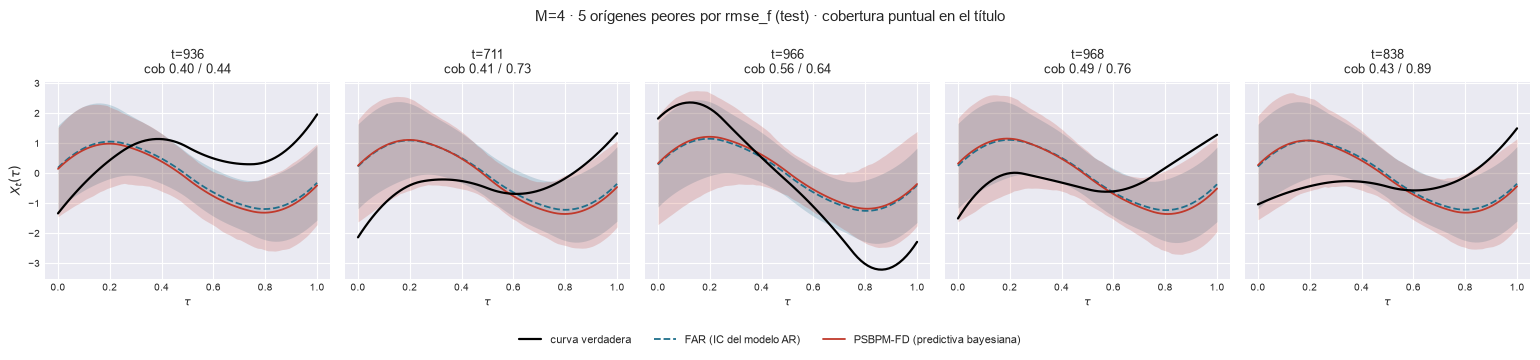

In [25]:
# Las dos bandas superpuestas sobre la misma curva. `plot_extractos_curvas`
# dibuja UNA banda, de modo que este contraste se arma aqui: es una vista
# especifica de esta seccion y no una primitiva reutilizable.
def _banda_por_prefijo(bandas_M, prefijo):
    for nombre in bandas_M:
        if nombre.startswith(prefijo):
            return nombre, bandas_M[nombre]
    return None, None


for M in EXTREMOS:
    e = EST[M]
    n1, b1 = _banda_por_prefijo(BANDAS[M], BANDA_A_CONTRASTAR[0])
    n2, b2 = _banda_por_prefijo(BANDAS[M], BANDA_A_CONTRASTAR[1])
    if b1 is None or b2 is None:
        print(f"[M={M}] no estan las dos bandas de BANDA_A_CONTRASTAR; se omite.")
        continue
    (li1, ls1), Xp1 = b1
    (li2, ls2), Xp2 = b2

    for etiqueta_grupo, indices in (("mejores", EXTREMOS[M]["mejores"]),
                                    ("peores",  EXTREMOS[M]["peores"])):
        fig, axes = plt.subplots(1, len(indices),
                                 figsize=(3.1 * len(indices), 3.2),
                                 sharey=True, squeeze=False)
        for ax, i in zip(axes[0], indices):
            ax.fill_between(grilla, li1[i], ls1[i], color="#1f6f8b", alpha=0.20,
                            lw=0, label=n1)
            ax.fill_between(grilla, li2[i], ls2[i], color="#c0392b", alpha=0.20,
                            lw=0, label=n2)
            ax.plot(grilla, Xp1[i], color="#1f6f8b", lw=1.3, ls="--")
            ax.plot(grilla, Xp2[i], color="#c0392b", lw=1.3)
            ax.plot(grilla, X_obj_ev[i], color="k", lw=1.6)
            cob1 = float(np.mean((X_obj_ev[i] >= li1[i]) & (X_obj_ev[i] <= ls1[i])))
            cob2 = float(np.mean((X_obj_ev[i] >= li2[i]) & (X_obj_ev[i] <= ls2[i])))
            ax.set_title(f"t={int(t_orig[i])}\ncob {cob1:.2f} / {cob2:.2f}",
                         fontsize=9)
            ax.tick_params(labelsize=7)
            ax.set_xlabel(r"$\tau$", fontsize=8)
        axes[0][0].set_ylabel(r"$X_t(\tau)$", fontsize=9)
        manijas = [
            plt.Line2D([], [], color="k", lw=1.6, label="curva verdadera"),
            plt.Line2D([], [], color="#1f6f8b", lw=1.3, ls="--", label=n1),
            plt.Line2D([], [], color="#c0392b", lw=1.3, label=n2),
        ]
        fig.legend(handles=manijas, loc="lower center", ncol=3, fontsize=8,
                   frameon=False, bbox_to_anchor=(0.5, -0.10))
        fig.suptitle(f"M={M} · {N_EXTREMOS} orígenes {etiqueta_grupo} por "
                     f"{METRICA_SEL_IC} (test) · cobertura puntual en el título",
                     fontsize=11)
        fig.tight_layout()
        fig.savefig(e["paths"]["out_report"]
                    / f"{PREFIJO + 9}_ic_contraste_{etiqueta_grupo}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()


In [26]:
# Ancho y cobertura por origen, de cada banda, en los mismos 2N origenes.
filas_ic = []
for M in EXTREMOS:
    e = EST[M]
    for etiqueta_grupo, indices in (("mejores", EXTREMOS[M]["mejores"]),
                                    ("peores",  EXTREMOS[M]["peores"])):
        for i in indices:
            for nombre, ((li, ls), _Xp) in BANDAS[M].items():
                dentro = (X_obj_ev[i] >= li[i]) & (X_obj_ev[i] <= ls[i])
                filas_ic.append({
                    "M": M, "grupo": etiqueta_grupo, "t": int(t_orig[i]),
                    "banda": nombre,
                    f"{METRICA_SEL_IC}_PSBPM": float(EXTREMOS[M]["serie"][i]),
                    "mpiw": float(np.mean(ls[i] - li[i])),
                    "picp_puntual": float(dentro.mean()),
                    "I_t_simultaneo": float(bool(dentro.all())),
                })

ic_df = pd.DataFrame(filas_ic)
for M in EXTREMOS:
    sub = ic_df[ic_df.M == M].set_index(["grupo", "t", "banda"])
    sub.drop(columns=["M"]).to_csv(
        EST[M]["paths"]["out_report"] / f"{PREFIJO + 9}_ic_contraste_origenes.csv")
    display(sub.drop(columns=["M"]).style
            .format({f"{METRICA_SEL_IC}_PSBPM": "{:.4f}", "mpiw": "{:.4f}",
                     "picp_puntual": "{:.3f}", "I_t_simultaneo": "{:.0f}"})
            .set_caption(f"M={M} · ancho y cobertura por origen · "
                         f"I_t_simultaneo = 1 si la banda contiene la curva "
                         "ENTERA"))

print("Lectura: si el MPIW del FAR es practicamente el mismo en los origenes")
print("mejores y en los peores, es porque su ancho NO depende del origen -su")
print("Sigma_eps es la misma para todo t-. Que el del PSBPM-FD SI cambie entre")
print("grupos es la flexibilidad que el escenario 1 no le deja aprovechar.")


Lectura: si el MPIW del FAR es practicamente el mismo en los origenes
mejores y en los peores, es porque su ancho NO depende del origen -su
Sigma_eps es la misma para todo t-. Que el del PSBPM-FD SI cambie entre
grupos es la flexibilidad que el escenario 1 no le deja aprovechar.
